# NDT7 EDA — ฟิลิปปินส์ (ภาพรวมประเทศ + รายจังหวัด)

ใช้ข้อมูลที่ทำความสะอาดแล้วจาก `data/ph/mlab_ph_clean.parquet` (สร้างโดย `mlab_ph_clean_v2.ipynb`)

- **fixed broadband** = `network_type = 'broadband'` · **mobile** = `network_type = 'cellular'`
- การวิเคราะห์ผู้บริโภคจะ filter เฉพาะสองประเภทนี้ (ตัด `hosting` / `unknown` ออกที่ระดับ query)
- ขอบเขต: ภาพรวมประเทศ + รายจังหวัด (GADM ADM1, 80 จังหวัดที่มีข้อมูล) — ไม่มีชั้น district ย่อยหรือข้อมูล GDP/ประชากร

## Part 0 · Setup

โหลด library, ชี้ path (แบบไม่ขึ้นกับ working directory), เปิด DuckDB connection โดยมองไฟล์ parquet เป็น view ชื่อ `t` พร้อม helper `q()` และตั้งค่า plot / สี fixed-mobile / SQL predicate ที่ใช้ซ้ำทั้งเล่ม

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from pathlib import Path

# --- resolve repo root regardless of the kernel's working dir ---
ROOT = Path.cwd()
while not (ROOT / 'data' / 'ph').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CLEAN   = ROOT / 'data' / 'ph' / 'mlab_ph_clean.parquet'
GEOJSON = ROOT / 'data' / 'ph' / 'gadm41_PHL_1.geojson'
ADM_FIELD = 'NAME_1'         
assert CLEAN.exists(),   f'missing {CLEAN}'
assert GEOJSON.exists(), f'missing {GEOJSON}'

# --- one DuckDB connection; expose the cleaned parquet as a view called `t` ---
con = duckdb.connect()
con.execute("SET max_memory='12GB'")   # 32GB box; leaves headroom for pandas/geopandas
con.execute(f"SET temp_directory='{(ROOT / '.tmp').as_posix()}'")   # spill to disk instead of OOM on a 262M-row scan
# --- exclude one monitoring/bot client IP that fired 865k tests and dominated SultanKudarat
#     (59% of that province's fixed-broadband download tests). Diagnosis: ndt7_ph_manila Part 3. ---
FLOOD_IPS = ('58.69.220.245',)
_flood = ', '.join(f"'{ip}'" for ip in FLOOD_IPS)
con.execute(f"CREATE OR REPLACE VIEW t AS SELECT * FROM read_parquet('{CLEAN.as_posix()}') "
            f"WHERE client_ip NOT IN ({_flood})")

def q(sql):
    """Run SQL against the cleaned PH dataset (exposed as view `t`) and return a DataFrame."""
    return con.execute(sql).df()

# --- reusable SQL predicates = the analysis vocabulary ---
FIXED  = "network_type = 'broadband'"   # consumer fixed line
MOBILE = "network_type = 'cellular'"    # consumer mobile
DL     = "type = 'download'"
UL     = "type = 'upload'"

# --- plotting defaults + a consistent fixed/mobile color pair used throughout ---
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
C_FIXED, C_MOBILE = '#0B6E5C', '#B8571F'

# --- sanity check ---
n_rows = con.execute("SELECT COUNT(*) FROM t").fetchone()[0]
print(f'ROOT    : {ROOT}')
print(f'CLEAN   : {CLEAN.name}  ({n_rows:,} rows)')
print(f'GEOJSON : {GEOJSON.name}')
print(f'excluded: {len(FLOOD_IPS)} flood IP(s) — {FLOOD_IPS}')                                                              

ROOT    : E:\ndt7
CLEAN   : mlab_ph_clean.parquet  (261,245,709 rows)
GEOJSON : gadm41_PHL_1.geojson
excluded: 1 flood IP(s) — ('58.69.220.245',)


# Part 1 · ภาพรวมประเทศ

### 1. ค่าสถิติพื้นฐานระดับประเทศ — throughput & RTT

แต่ละแถว = การทดสอบหนึ่งทิศทาง (download/upload แยกแถวกัน) จึงแยกสถิติเป็น **fixed/mobile × download/upload** เพื่อไม่ให้ค่าเฉลี่ยปนกัน แสดง mean / median / std ของความเร็ว (`mean_throughput_mbps`) และ latency (`min_rtt`) เฉพาะ traffic ผู้บริโภค (broadband + cellular)

> **หมายเหตุ RTT:** `min_rtt` มี outlier ปนอยู่ ~0.07% (ค่าสูงสุดถึง 4.29M ms — measurement artifact) ซึ่งทำให้ mean/std เพี้ยนหนัก จึงคิด mean/std ของ RTT เฉพาะช่วงที่เป็นไปได้จริง (`< 2000 ms`) ส่วน **median ใช้ข้อมูลเต็ม** เพราะทนต่อ outlier อยู่แล้ว · throughput ไม่มีปัญหานี้ (ค่าสูงสุด 5.4 Gbps สมเหตุสมผลกับไฟเบอร์) จึงใช้ทุกแถว

In [2]:
national = q(f"""
    SELECT
        CASE WHEN {FIXED} THEN 'fixed' ELSE 'mobile' END AS segment,
        type AS direction,
        COUNT(*)                                 AS n,
        ROUND(AVG(mean_throughput_mbps),   1)    AS mean,
        ROUND(MEDIAN(mean_throughput_mbps),1)    AS median,
        ROUND(STDDEV(mean_throughput_mbps),1)    AS std,
        -- min_rtt has ~0.07% garbage outliers (up to 4.29M ms, measurement artifacts)
        -- that wreck mean/std. median is robust -> uses all rows; mean/std are computed
        -- only over the physically-plausible range (< 2000 ms).
        ROUND(AVG(min_rtt)    FILTER (WHERE min_rtt < 2000), 1) AS rtt_mean,
        ROUND(MEDIAN(min_rtt), 1)                               AS rtt_median,
        ROUND(STDDEV(min_rtt) FILTER (WHERE min_rtt < 2000), 1) AS rtt_std
    FROM t
    WHERE {FIXED} OR {MOBILE}
    GROUP BY 1, 2
    ORDER BY 1, 2
""")
national

,segment,direction,n,mean,median,std,rtt_mean,rtt_median,rtt_std
0,fixed,download,90938041,66.3,31.2,91.7,67.8,50.5,86.6
1,fixed,upload,70368858,48.1,18.6,74.8,69.5,52.3,85.9
2,mobile,download,55985519,38.3,10.9,76.7,63.4,44.0,85.0
3,mobile,upload,40206659,21.7,3.2,58.0,64.3,45.2,85.3


### 2. แผนที่ความเร็ว fixed broadband รายจังหวัด (choropleth)

ค่าเฉลี่ยความเร็ว download ของ fixed broadband ต่อจังหวัด **เฉลี่ยรวมทุกช่วงเวลา (2023–2025)** — test-weighted average = `AVG(mean_throughput_mbps)` ต่อจังหวัด แบ่งเป็น bin สีแบบ discrete (viridis) จังหวัดที่ไม่มีข้อมูลแสดงเป็นสีขาว

> ข้อมูลจริงเกือบทุกจังหวัดอยู่ในช่วง 0–100 Mbps (47 จังหวัด 0-50, 31 จังหวัด 50-100) มีเพียง SultanKudarat จังหวัดเดียวที่แตะ 100-200 (169.5 Mbps, n≈123k) — เป็น outlier ที่ควรอ่านด้วยความระวังเรื่อง sample size · 79 จาก 81 จังหวัดใน GADM มีข้อมูล fixed broadband (Batanes ไม่มี test เลย, Tawi-Tawi มีแต่ไม่มี fixed download)

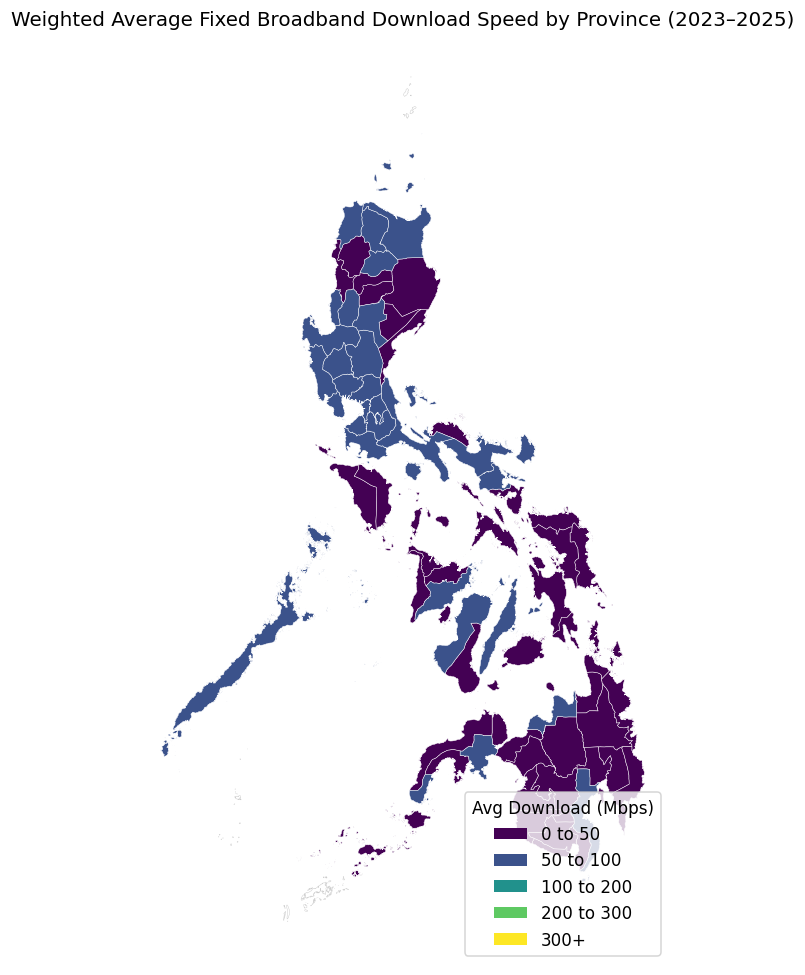

all periods: 79 provinces with fixed-broadband data | overall national avg = 66.3 Mbps


In [3]:
from matplotlib.patches import Patch

# --- test-weighted average download per province, all periods (2023-2025) ---
prov_dl = q(f"""
    SELECT province, AVG(mean_throughput_mbps) AS avg_dl, COUNT(*) AS n
    FROM t
    WHERE {FIXED} AND {DL} AND province IS NOT NULL
    GROUP BY 1
""")

gmap = (gpd.read_file(GEOJSON)[[ADM_FIELD, 'geometry']]
        .rename(columns={ADM_FIELD: 'province'})
        .merge(prov_dl, on='province', how='left'))

bins   = [0, 50, 100, 200, 300, np.inf]
labels = ['0 to 50', '50 to 100', '100 to 200', '200 to 300', '300+']
colors = [plt.cm.viridis(x) for x in np.linspace(0, 1, len(labels))]
gmap['bin'] = pd.cut(gmap['avg_dl'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(9, 9))
gmap[gmap['avg_dl'].isna()].plot(ax=ax, color='white', edgecolor='#cccccc', linewidth=0.3)
for lab, col in zip(labels, colors):
    sub = gmap[gmap['bin'] == lab]
    if len(sub):
        sub.plot(ax=ax, color=col, edgecolor='white', linewidth=0.3)

ax.set_title('Weighted Average Fixed Broadband Download Speed by Province (2023–2025)', fontsize=13)
ax.axis('off')
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in zip(labels, colors)],
          title='Avg Download (Mbps)', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

n_matched = gmap['avg_dl'].notna().sum()
print(f'all periods: {n_matched} provinces with fixed-broadband data '
      f'| overall national avg = '
      f'{q(f"SELECT AVG(mean_throughput_mbps) a FROM t WHERE {FIXED} AND {DL}")["a"][0]:.1f} Mbps')

### 3. แผนที่ความเร็ว mobile รายจังหวัด (choropleth)

เหมือน §2 ทุกอย่าง (test-weighted average download รายจังหวัด, เฉลี่ยรวม 2023–2025, viridis, legend มุมขวาล่าง) แต่เปลี่ยนเป็น mobile (`network_type = 'cellular'`)

> **สำคัญ — bin ต่างจากแผนที่ fixed:** mobile ช้ากว่า fixed ~2 เท่า (province avg สูงสุด 61.0 Mbps ที่ Catanduanes) ถ้าใช้ bin ชุดเดียวกับ fixed (0-50/50-100/…) จะได้ 52 จาก 59 จังหวัดเป็นสีเดียว จึงใช้ bin ที่เหมาะกับ mobile (`0/10/20/30/50+`) แทน — **สองแผนที่นี้จึงเทียบสีตรง ๆ กันไม่ได้** ให้ดูค่าตัวเลขในแต่ละ legend ประกอบ

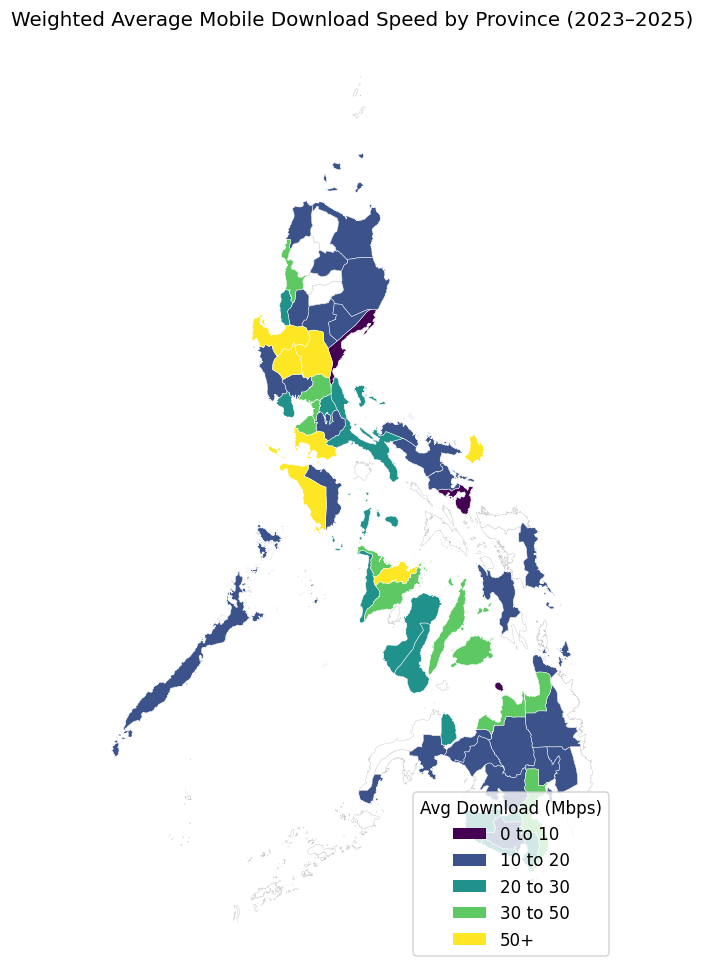

all periods: 59 provinces with mobile data | overall national avg = 38.3 Mbps


In [4]:
from matplotlib.patches import Patch

# --- test-weighted average mobile download per province, all periods (2023-2025) ---
prov_mob = q(f"""
    SELECT province, AVG(mean_throughput_mbps) AS avg_dl, COUNT(*) AS n
    FROM t
    WHERE {MOBILE} AND {DL} AND province IS NOT NULL
    GROUP BY 1
""")

gmap_m = (gpd.read_file(GEOJSON)[[ADM_FIELD, 'geometry']]
          .rename(columns={ADM_FIELD: 'province'})
          .merge(prov_mob, on='province', how='left'))

# mobile-scaled bins (fixed's 0/50/100/... would collapse ~88% of provinces into one color)
bins   = [0, 10, 20, 30, 50, np.inf]
labels = ['0 to 10', '10 to 20', '20 to 30', '30 to 50', '50+']
colors = [plt.cm.viridis(x) for x in np.linspace(0, 1, len(labels))]
gmap_m['bin'] = pd.cut(gmap_m['avg_dl'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(9, 9))
gmap_m[gmap_m['avg_dl'].isna()].plot(ax=ax, color='white', edgecolor='#cccccc', linewidth=0.3)
for lab, col in zip(labels, colors):
    sub = gmap_m[gmap_m['bin'] == lab]
    if len(sub):
        sub.plot(ax=ax, color=col, edgecolor='white', linewidth=0.3)

ax.set_title('Weighted Average Mobile Download Speed by Province (2023–2025)', fontsize=13)
ax.axis('off')
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in zip(labels, colors)],
          title='Avg Download (Mbps)', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

n_matched = gmap_m['avg_dl'].notna().sum()
print(f'all periods: {n_matched} provinces with mobile data '
      f'| overall national avg = '
      f'{q(f"SELECT AVG(mean_throughput_mbps) a FROM t WHERE {MOBILE} AND {DL}")["a"][0]:.1f} Mbps')

## Geographic mapping — province → region → island

v2 parquet มีคอลัมน์ `region` มาให้แล้ว (17 ภูมิภาค) จึง **ไม่ต้องสร้าง mapping จังหวัด→ภูมิภาคเองอีกต่อไป** —
เหลือแค่ชั้นบนสุด region→island group ที่ยังไม่มีในข้อมูล สร้างที่นี่ แล้ว register เป็นตาราง `reg_map`
(province, region, island) ใน DuckDB เพื่อให้ทุกส่วนถัดไป (Part 2 เกาะ, Part 3 region, Part 4 จังหวัด) join ใช้ร่วมกัน
· `assert` กันกรณีมี region ในข้อมูลที่หลุด ISLAND map

> **ลำดับชั้นให้ชัด (กันสับสน):** `province` (คอลัมน์ดิบจาก GADM ADM1, 81 หน่วย เช่น `Cebu`, `DavaodelSur`,
> `MetropolitanManila`) ⊂ `region` (คอลัมน์ดิบจาก M-Lab, 17 หน่วย เช่น `NCR`, `CAR`, `Region I`–`XIII`, `BARMM`,
> `MIMAROPA`) ⊂ `island` (**ไม่ใช่คอลัมน์ในข้อมูล** — สร้างขึ้นในโน้ตบุ๊กนี้จาก dict `ISLAND` ด้านล่าง 3 หน่วย:
> Luzon/Visayas/Mindanao) · ทุกกราฟที่บอกว่า "by region" = 17 แท่ง, ทุกกราฟที่บอกว่า "by island" = 3 แท่ง —
> ไม่มีกราฟไหนสลับคอลัมน์กัน แค่สีของแท่ง region มักระบายตาม island เพื่อให้เห็น pattern เหนือ-ใต้ด้วย

In [5]:
import sys
from matplotlib.patches import Patch

# --- region -> island group, imported from a single shared source (not redefined per
# notebook) so ndt7_ph_main.ipynb and ndt7_ph_paper.ipynb can never drift apart. ---
sys.path.insert(0, str(ROOT / 'ip_fetch' / 'srs'))
from ph_island_map import REGION_TO_ISLAND as ISLAND, ISLAND_COLORS

reg_map = q("""
    SELECT DISTINCT province, region
    FROM t
    WHERE province IS NOT NULL AND region IS NOT NULL
""")
# fail loudly rather than silently dropping a region's tests in every downstream join
_missing = sorted(set(reg_map['region']) - set(ISLAND))
assert not _missing, f'region(s) not in the ISLAND map: {_missing}'
reg_map['island'] = reg_map['region'].map(ISLAND)
con.register('reg_map', reg_map)

print(f'reg_map: {len(reg_map)} provinces -> {reg_map.region.nunique()} regions -> {reg_map.island.nunique()} islands')
print(reg_map.groupby('island').province.count().to_string())

reg_map: 80 provinces -> 17 regions -> 3 islands
island
Luzon       38
Mindanao    26
Visayas     16


# Part 2 · สรุประดับเกาะ (3 island groups — ไม่ใช่ 17 regions) — North–South Digital Divide

ภาพสรุปบนสุดของการวิเคราะห์เชิงพื้นที่: ยุบ 17 regions เป็น **3 กลุ่มเกาะ** (Luzon / Visayas / Mindanao) เพื่อเล่า story หลักของ PH — ความเหลื่อมล้ำเหนือ-ใต้ ก่อนจะซูมลงราย region (Part 3) และรายจังหวัด (Part 4)

> เล่มนี้มี 3 ระดับพื้นที่: **island (3, เกาะ — เล่มนี้)** → **region (17, ภูมิภาค — Part 3)** → **province (81, จังหวัด — Part 4)** ดูรายละเอียด mapping ที่ cell "Geographic mapping" ด้านบน

- **panel ซ้าย/กลาง:** ความเร็ว download แยก fixed vs mobile ต่อเกาะ — ทำทั้ง **mean** และ **median** (share แกน y เพื่อให้เห็นว่า mean สูงกว่า median = การแจกแจงเบ้ขวา มี connection เร็ว ๆ ลากค่าเฉลี่ยขึ้น)
- **panel ขวา:** *mobile reliance* = สัดส่วน test ที่เป็น mobile — ยิ่งสูงยิ่งบ่งชี้ว่าพื้นที่นั้นพึ่งมือถือ (เพราะเน็ตบ้านเข้าไม่ถึง)
- ใต้แต่ละแท่งบอก n (จำนวน test) + จำนวนจังหวัด เพื่อเห็น representativeness (Luzon ครอง ~71% ของ test)

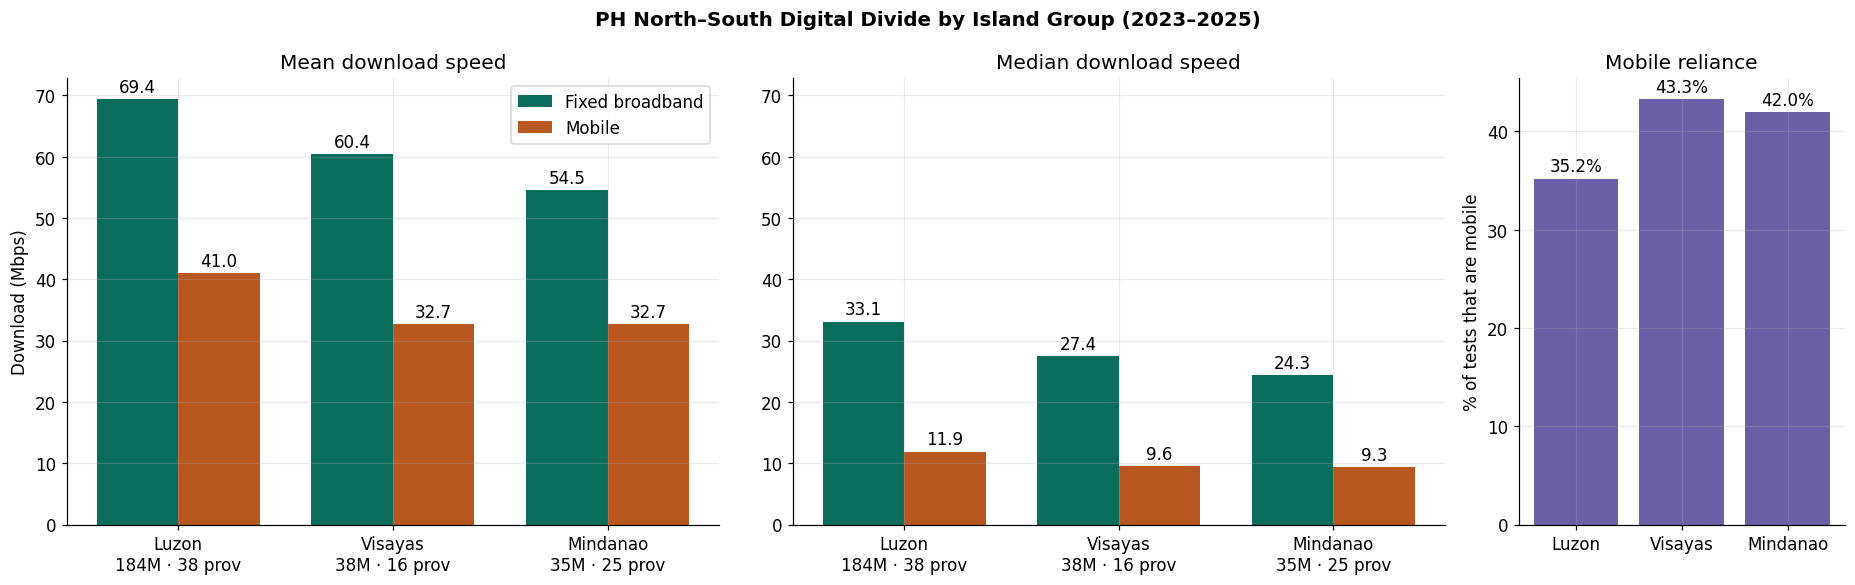

,island,tests,provinces,mobile_reliance_pct,fixed_dl_mean,fixed_dl_med,mobile_dl_mean,mobile_dl_med
0,Luzon,184110640,38,35.2,69.4,33.1,41.0,11.9
1,Visayas,38352935,16,43.3,60.4,27.4,32.7,9.6
2,Mindanao,35035477,25,42.0,54.5,24.3,32.7,9.3


In [6]:
island = q("""
    SELECT m.island,
           COUNT(*)                                                               AS tests,
           COUNT(DISTINCT t.province)                                             AS provinces,
           ROUND(100.0*SUM(CASE WHEN network_type='cellular' THEN 1 ELSE 0 END)/COUNT(*), 1) AS mobile_reliance_pct,
           ROUND(AVG(CASE    WHEN network_type='broadband' AND type='download' THEN mean_throughput_mbps END), 1) AS fixed_dl_mean,
           ROUND(MEDIAN(CASE WHEN network_type='broadband' AND type='download' THEN mean_throughput_mbps END), 1) AS fixed_dl_med,
           ROUND(AVG(CASE    WHEN network_type='cellular'  AND type='download' THEN mean_throughput_mbps END), 1) AS mobile_dl_mean,
           ROUND(MEDIAN(CASE WHEN network_type='cellular'  AND type='download' THEN mean_throughput_mbps END), 1) AS mobile_dl_med
    FROM t JOIN reg_map m ON t.province = m.province
    WHERE network_type IN ('broadband', 'cellular')
    GROUP BY 1
""").set_index('island').loc[['Luzon', 'Visayas', 'Mindanao']].reset_index()   # order North -> South

x, w = np.arange(3), 0.38
fig, (axm, axmd, axr) = plt.subplots(1, 3, figsize=(17, 5.4),
                                     gridspec_kw={'width_ratios': [2, 2, 1]})

# two speed panels (Mean / Median), fixed vs mobile — shared y so the mean > median skew is visible
for ax, fcol, mcol, ttl in [(axm, 'fixed_dl_mean', 'mobile_dl_mean', 'Mean'),
                            (axmd, 'fixed_dl_med',  'mobile_dl_med',  'Median')]:
    b1 = ax.bar(x - w/2, island[fcol], w, label='Fixed broadband', color=C_FIXED)
    b2 = ax.bar(x + w/2, island[mcol], w, label='Mobile',          color=C_MOBILE)
    ax.bar_label(b1, fmt='%.1f', padding=2)
    ax.bar_label(b2, fmt='%.1f', padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r.island}\n{r.tests/1e6:.0f}M · {r.provinces} prov' for _, r in island.iterrows()])
    ax.set_title(f'{ttl} download speed')
axm.set_ylabel('Download (Mbps)')
axmd.sharey(axm)
axm.legend()

# mobile reliance panel
bb = axr.bar(x, island['mobile_reliance_pct'], color='#6C5FA8')
axr.bar_label(bb, fmt='%.1f%%', padding=2)
axr.set_xticks(x)
axr.set_xticklabels(island['island'])
axr.set_ylabel('% of tests that are mobile')
axr.set_title('Mobile reliance')

fig.suptitle('PH North–South Digital Divide by Island Group (2023–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

island

# Part 3 · รายภูมิภาค (17 regions)

### 4. Fixed broadband — ความเร็ว download รายภูมิภาค (mean & median)

ซูมจากระดับเกาะ (Part 2) ลงมาราย **17 ภูมิภาค** ระบายสีตามหมู่เกาะ (Luzon / Visayas / Mindanao) ใช้ `reg_map` จาก Geographic mapping cell

- **metric:** ค่าเฉลี่ยราย region *ต่อไตรมาส* (test-weighted) แล้วเฉลี่ยข้าม 12 ไตรมาส (2023 Q1 – 2025 Q4) เพื่อให้แต่ละไตรมาสมีน้ำหนักเท่ากัน (ไม่ให้ปี 2025 ที่ทดสอบเยอะกลบปีอื่น)
- **ตัวเลขในแท่ง** = จำนวน test ทั้งหมด (n) · **เส้นประ** = ค่าเฉลี่ยของทุกภูมิภาค
- ทำทั้ง **mean** (panel ซ้าย) และ **median** (panel ขวา) — เรียงตาม mean เหมือนกันทั้งสอง panel เพื่อเทียบว่าภูมิภาคไหน mean กับ median ต่างกันมาก

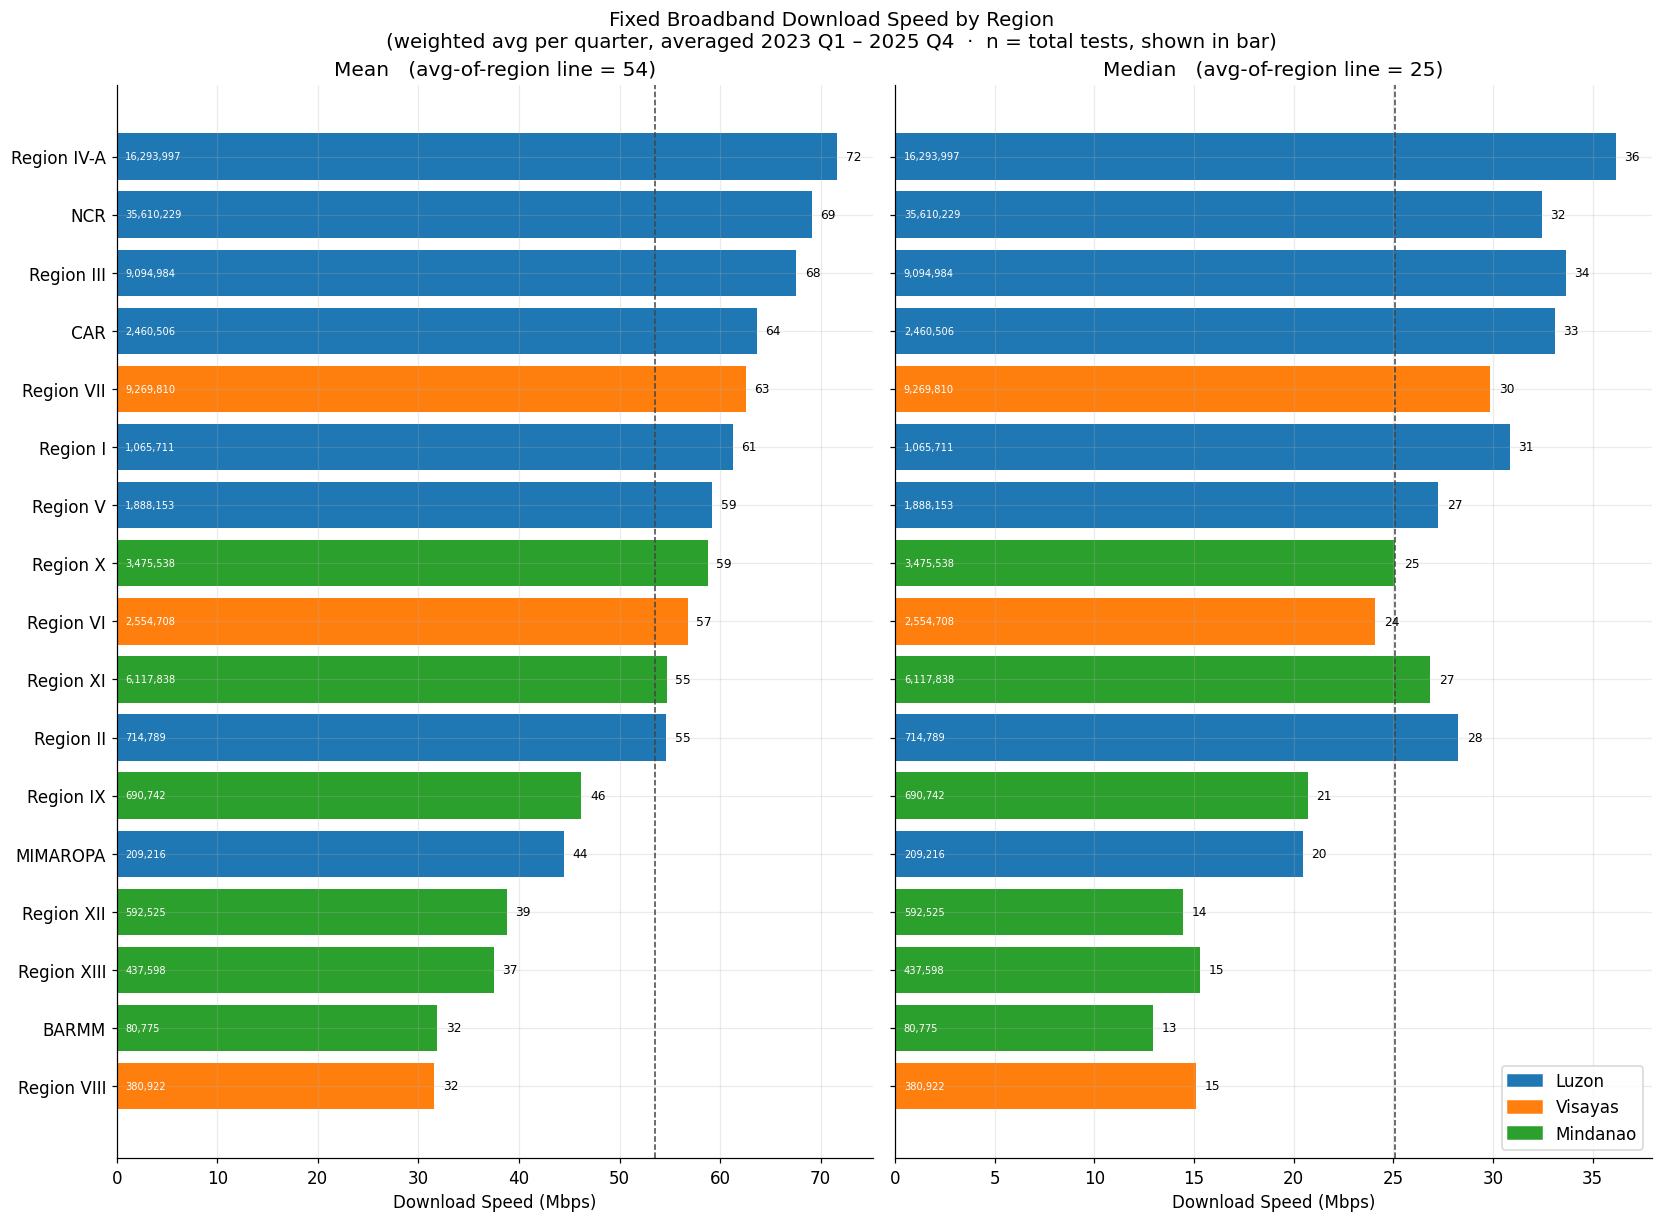

In [7]:
def region_speed_figure(net_pred, seg_label):
    """Region bar chart (mean | median panels) for one network type.
    metric = per-region test-weighted average per quarter, then averaged across all
    quarters 2023Q1-2025Q4; n (in bar) = total tests; dashed line = mean across regions.
    Uses reg_map / ISLAND_COLORS from the Geographic mapping cell."""
    agg = q(f"""
        WITH rq AS (
            SELECT m.region, m.island, t.year, CAST(CEIL(t.month/3.0) AS INT) AS quarter,
                   AVG(t.mean_throughput_mbps)    AS q_mean,
                   MEDIAN(t.mean_throughput_mbps) AS q_median,
                   COUNT(*)                       AS q_n
            FROM t JOIN reg_map m ON t.province = m.province
            WHERE {net_pred} AND {DL}
            GROUP BY 1, 2, 3, 4
        )
        SELECT region, island,
               AVG(q_mean)   AS mean_spd,
               AVG(q_median) AS median_spd,
               SUM(q_n)      AS total_tests
        FROM rq GROUP BY 1, 2
    """).sort_values('mean_spd').reset_index(drop=True)

    y = np.arange(len(agg))
    cols = [ISLAND_COLORS[i] for i in agg['island']]
    fig, axes = plt.subplots(1, 2, figsize=(15, 11), sharey=True, constrained_layout=True)
    for ax, mcol, ttl in [(axes[0], 'mean_spd', 'Mean'), (axes[1], 'median_spd', 'Median')]:
        ax.barh(y, agg[mcol], color=cols)
        ref, mx = agg[mcol].mean(), agg[mcol].max()
        ax.axvline(ref, ls='--', color='#444', lw=1)
        for yi, v, n in zip(y, agg[mcol], agg['total_tests']):
            ax.text(v + mx * 0.012, yi, f'{v:.0f}', va='center', fontsize=8)
            ax.text(mx * 0.012, yi, f'{n:,.0f}', va='center', fontsize=6.5, color='white')
        ax.set_title(f'{ttl}   (avg-of-region line = {ref:.0f})')
        ax.set_xlabel('Download Speed (Mbps)')
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(agg['region'])
    axes[1].legend(handles=[Patch(color=c, label=l) for l, c in ISLAND_COLORS.items()],
                   loc='lower right', frameon=True)
    fig.suptitle(f'{seg_label} Download Speed by Region\n'
                 f'(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4  ·  n = total tests, shown in bar)',
                 fontsize=13)
    plt.show()
    return agg

fixed_by_region = region_speed_figure(FIXED, 'Fixed Broadband')

### 5. Cellular / Mobile — ความเร็ว download รายภูมิภาค (mean & median)

เหมือน §4 ทุกอย่าง แต่เปลี่ยนเป็น mobile (`network_type = 'cellular'`) — ใช้ helper `region_speed_figure()` ตัวเดียวกัน แกน x ปรับสเกลอัตโนมัติตามค่าของ mobile (ช้ากว่า fixed) จึงเทียบขนาดแท่งข้าม §4/§5 ตรง ๆ ไม่ได้ ให้ดูตัวเลขประกอบ

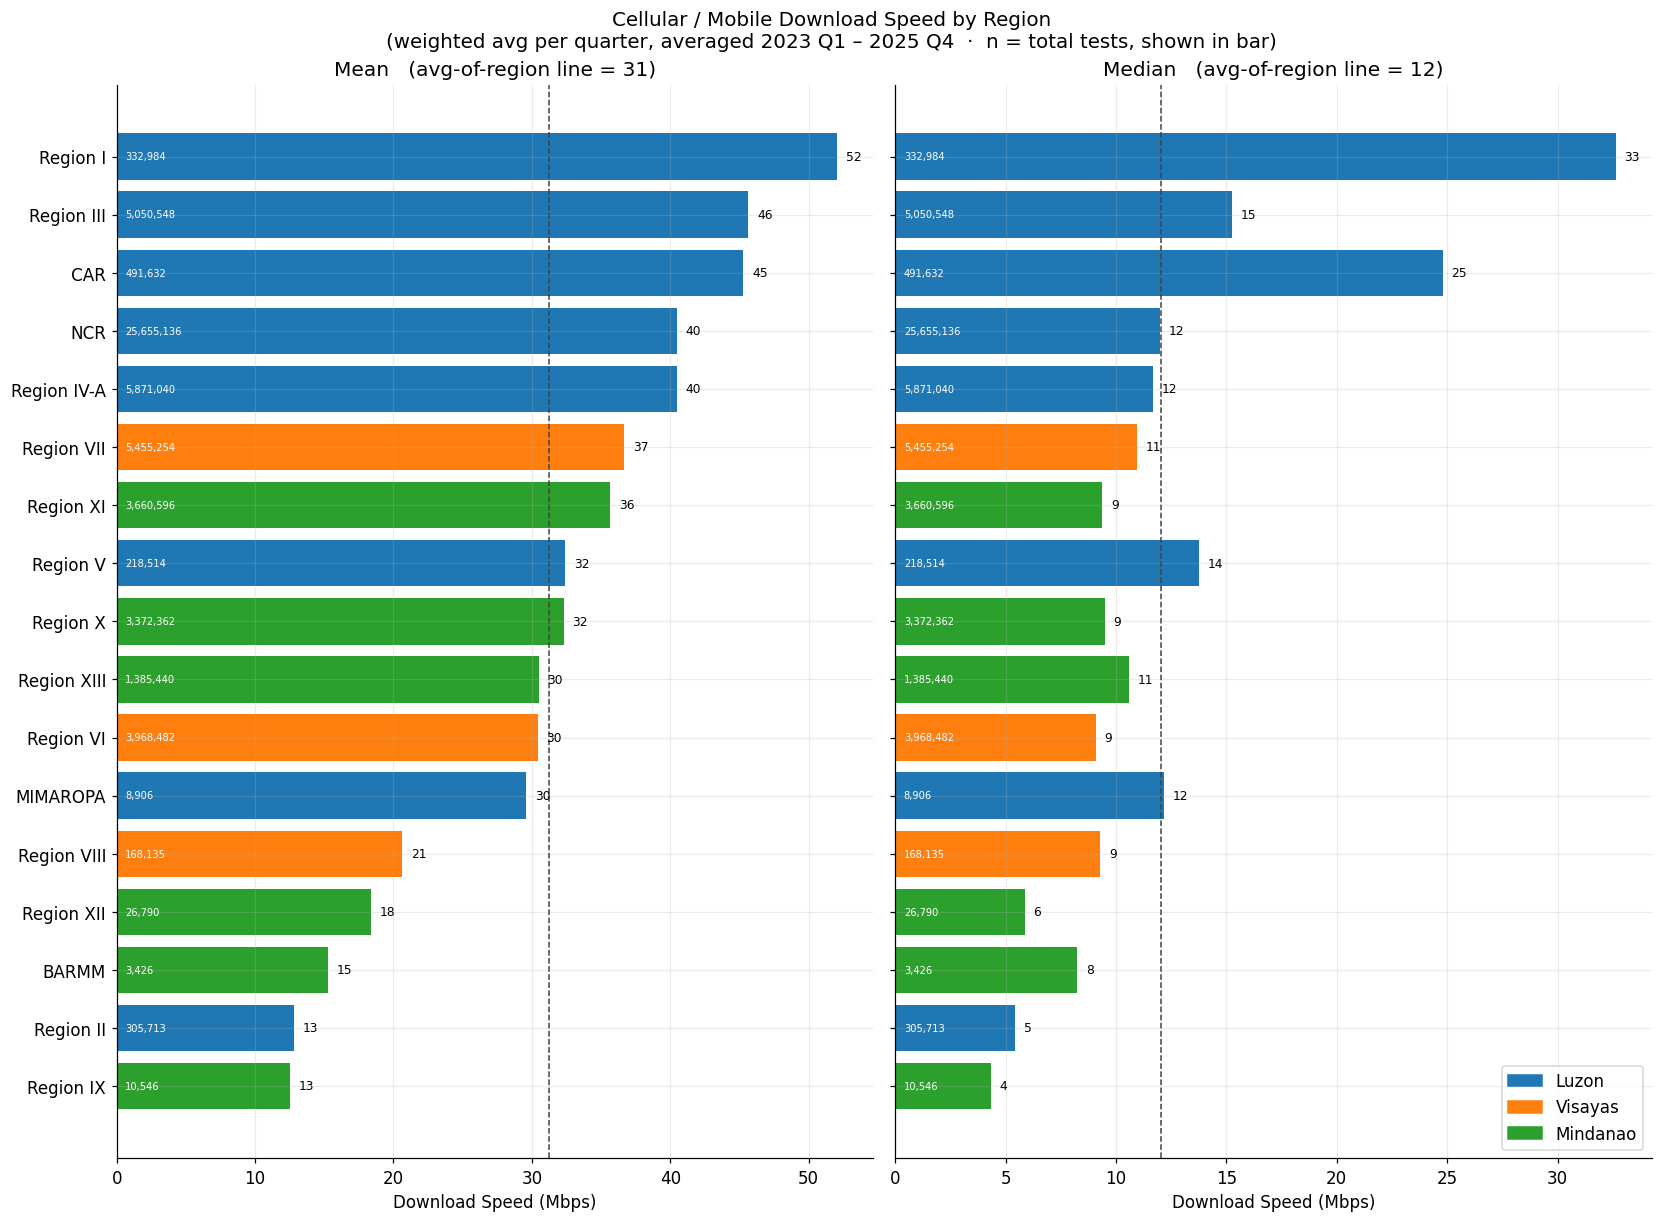

In [8]:
mobile_by_region = region_speed_figure(MOBILE, 'Cellular / Mobile')

# Part 4 · รายจังหวัด (GADM ADM1, 80 จังหวัดที่มีข้อมูล)

### 6. Fixed broadband — ความเร็ว download รายจังหวัด (mean & median)

ซูมลึกสุดถึงระดับจังหวัด (GADM ADM1 — NCR ถูกยุบเป็นหน่วยเดียว `MetropolitanManila` = เขตเมืองหลวงทั้งก้อน) ระบายสีตามหมู่เกาะเช่นเดิม ใช้ metric เดียวกับ Part 3 (weighted avg ต่อไตรมาส แล้วเฉลี่ยข้ามไตรมาส) · **ตัวเลขในแท่ง = n (จำนวน test)** สำคัญมากที่ระดับจังหวัด เพราะบางจังหวัดมี test น้อยหลักพัน/หลักร้อย ค่าจึงผันผวน — ดู n ประกอบทุกครั้ง

> ปรับ `min_tests` ใน helper เพื่อกรองจังหวัดที่ข้อมูลน้อยออก (default = 0 คือแสดงทุกจังหวัด) · **Sultan Kudarat นำลิ่ว** เป็น outlier ที่ควรระวัง (กระจุกที่ ISP เดียว)

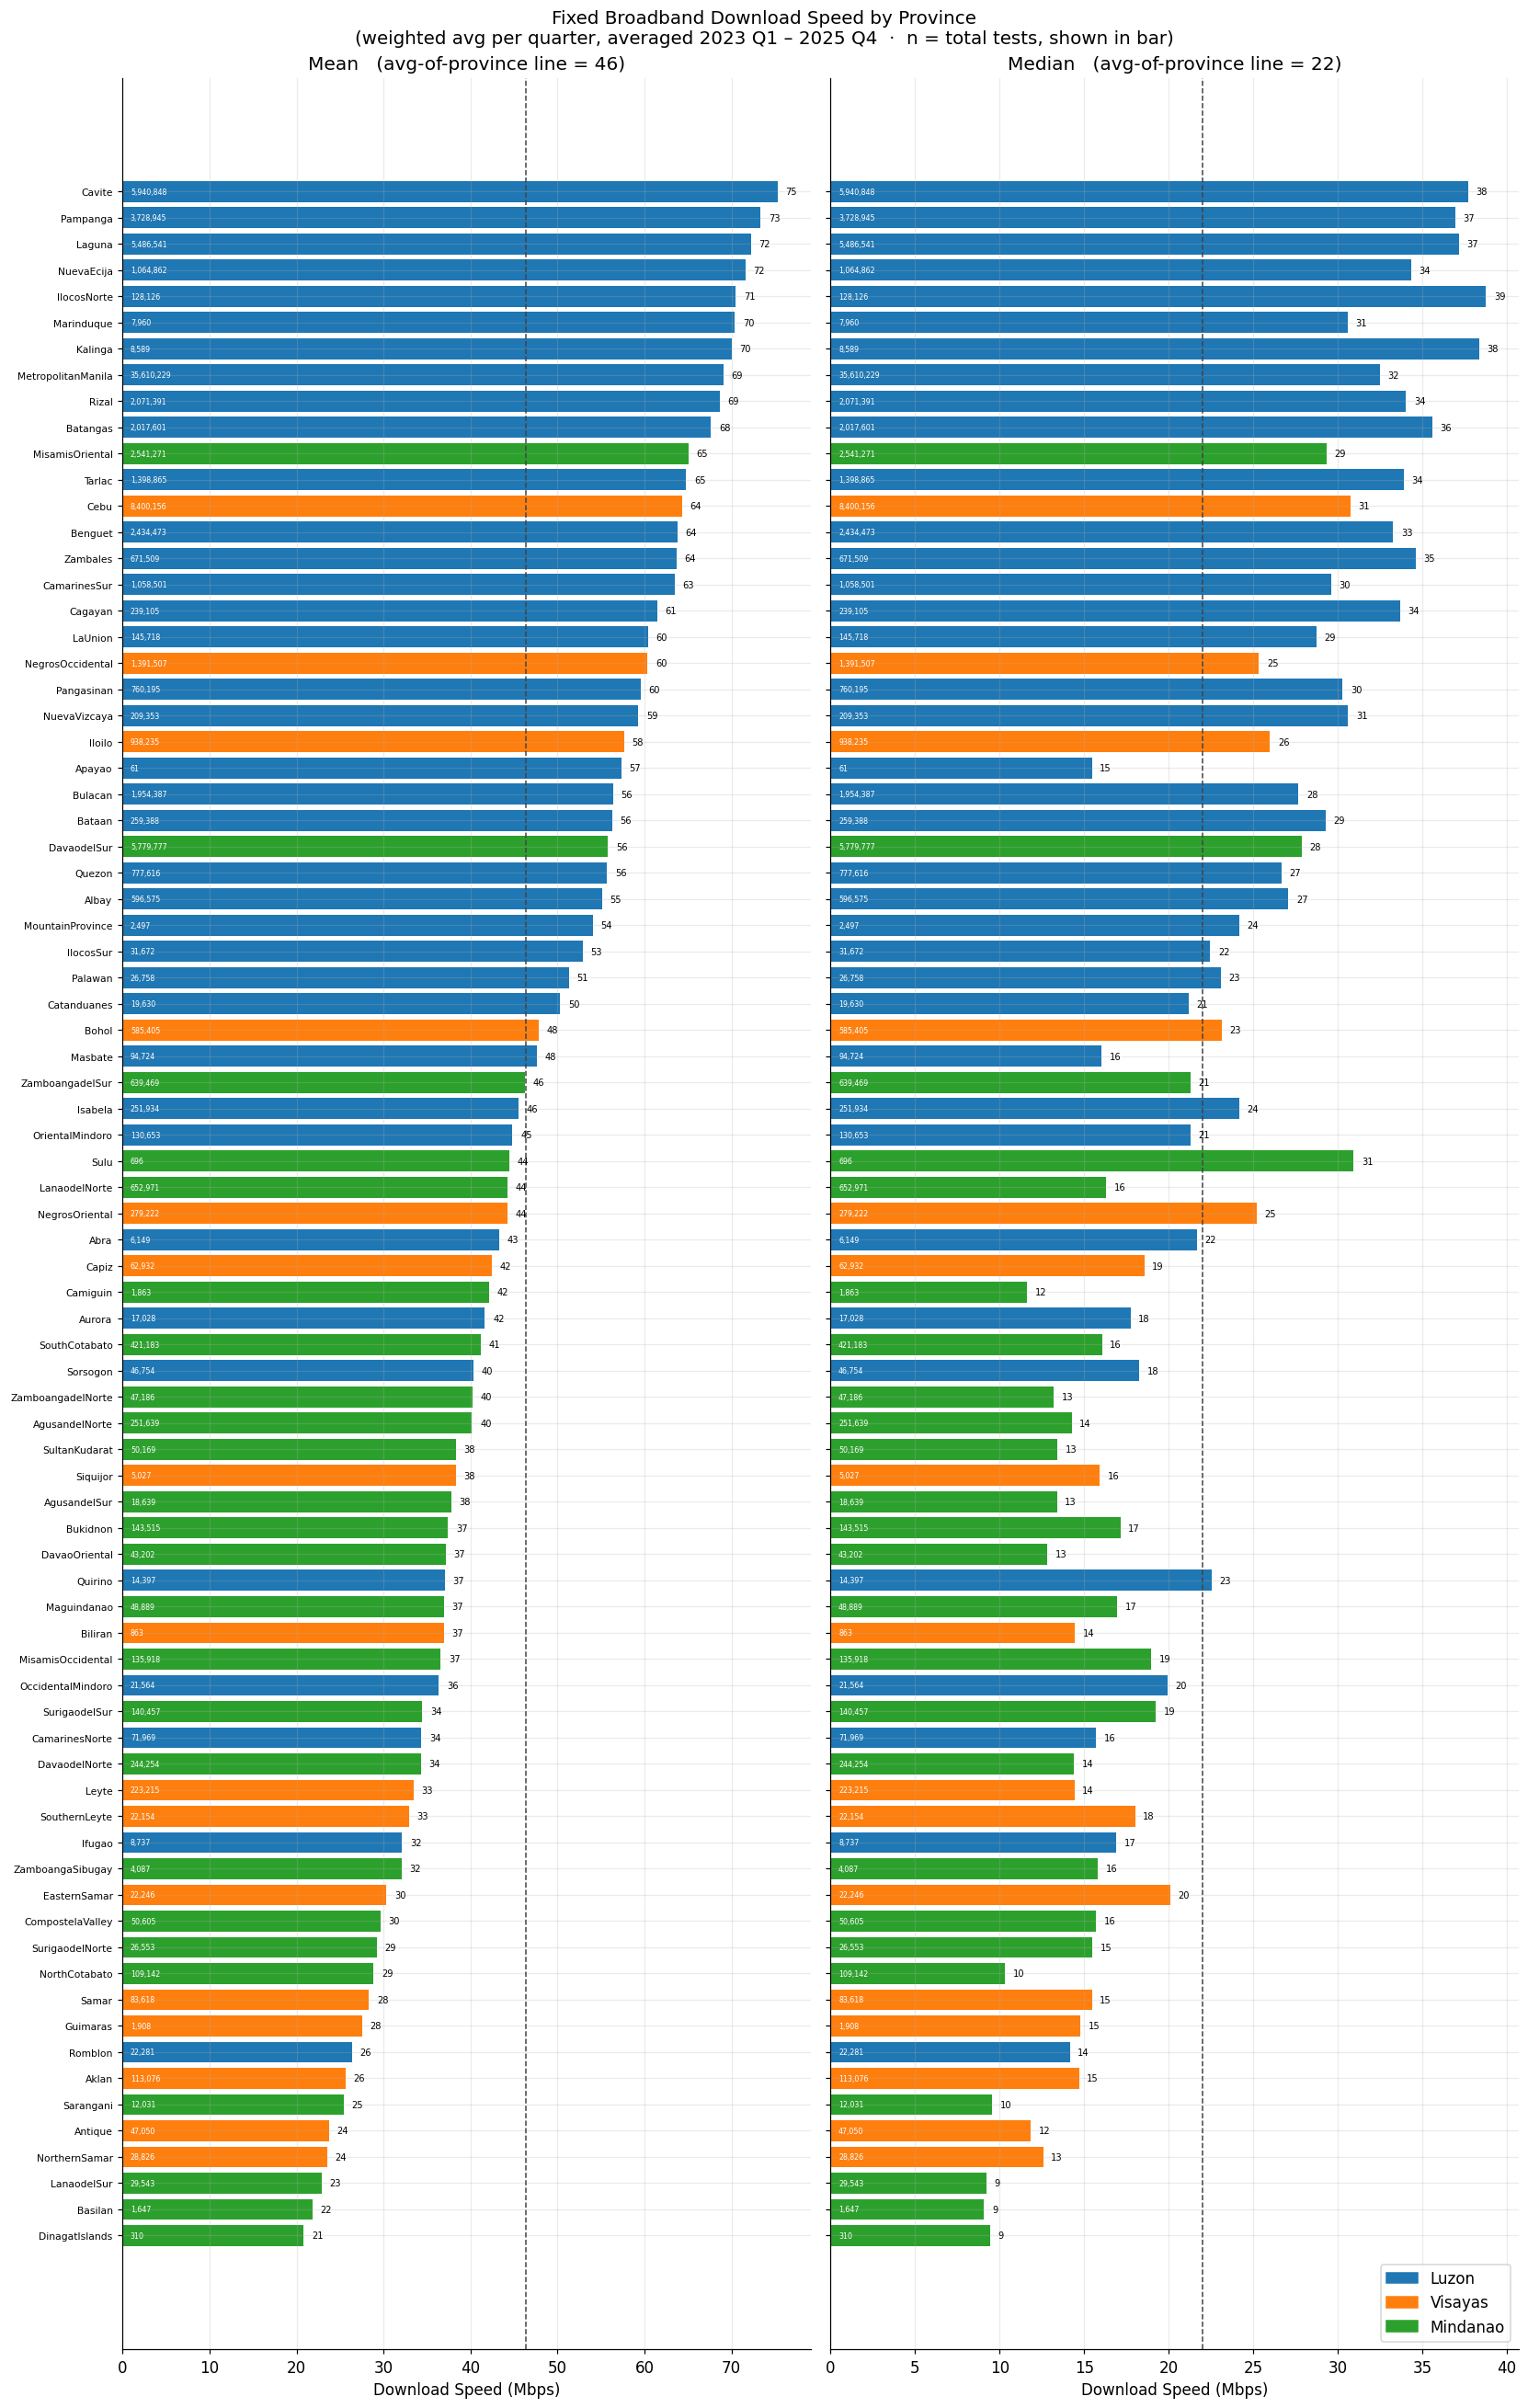

In [9]:
def province_speed_figure(net_pred, seg_label, min_tests=0):
    """Province (GADM ADM1) bar chart (mean | median panels) for one network type. Same metric
    as region_speed_figure but grouped by province, colored by island. min_tests drops
    provinces with fewer than that many total tests (default 0 = show all)."""
    agg = q(f"""
        WITH rq AS (
            SELECT t.province, m.island, t.year, CAST(CEIL(t.month/3.0) AS INT) AS quarter,
                   AVG(t.mean_throughput_mbps)    AS q_mean,
                   MEDIAN(t.mean_throughput_mbps) AS q_median,
                   COUNT(*)                       AS q_n
            FROM t JOIN reg_map m ON t.province = m.province
            WHERE {net_pred} AND {DL}
            GROUP BY 1, 2, 3, 4
        )
        SELECT province, island,
               AVG(q_mean)   AS mean_spd,
               AVG(q_median) AS median_spd,
               SUM(q_n)      AS total_tests
        FROM rq GROUP BY 1, 2
        HAVING SUM(q_n) >= {min_tests}
    """).sort_values('mean_spd').reset_index(drop=True)

    y = np.arange(len(agg))
    cols = [ISLAND_COLORS[i] for i in agg['island']]
    fig, axes = plt.subplots(1, 2, figsize=(15, max(8, len(agg) * 0.30)), sharey=True,
                             constrained_layout=True)
    for ax, mcol, ttl in [(axes[0], 'mean_spd', 'Mean'), (axes[1], 'median_spd', 'Median')]:
        ax.barh(y, agg[mcol], color=cols)
        ref, mx = agg[mcol].mean(), agg[mcol].max()
        ax.axvline(ref, ls='--', color='#444', lw=1)
        for yi, v, n in zip(y, agg[mcol], agg['total_tests']):
            ax.text(v + mx * 0.012, yi, f'{v:.0f}', va='center', fontsize=6.5)
            ax.text(mx * 0.012, yi, f'{n:,.0f}', va='center', fontsize=5.2, color='white')
        ax.set_title(f'{ttl}   (avg-of-province line = {ref:.0f})')
        ax.set_xlabel('Download Speed (Mbps)')
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(agg['province'], fontsize=7)
    axes[1].legend(handles=[Patch(color=c, label=l) for l, c in ISLAND_COLORS.items()],
                   loc='lower right', frameon=True)
    fig.suptitle(f'{seg_label} Download Speed by Province\n'
                 f'(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4  ·  n = total tests, shown in bar)',
                 fontsize=13)
    plt.show()
    return agg

fixed_by_province = province_speed_figure(FIXED, 'Fixed Broadband')

### 7. Cellular / Mobile — ความเร็ว download รายจังหวัด (mean & median)

เหมือน §6 แต่เปลี่ยนเป็น mobile (`network_type = 'cellular'`) ใช้ helper `province_speed_figure()` ตัวเดียวกัน

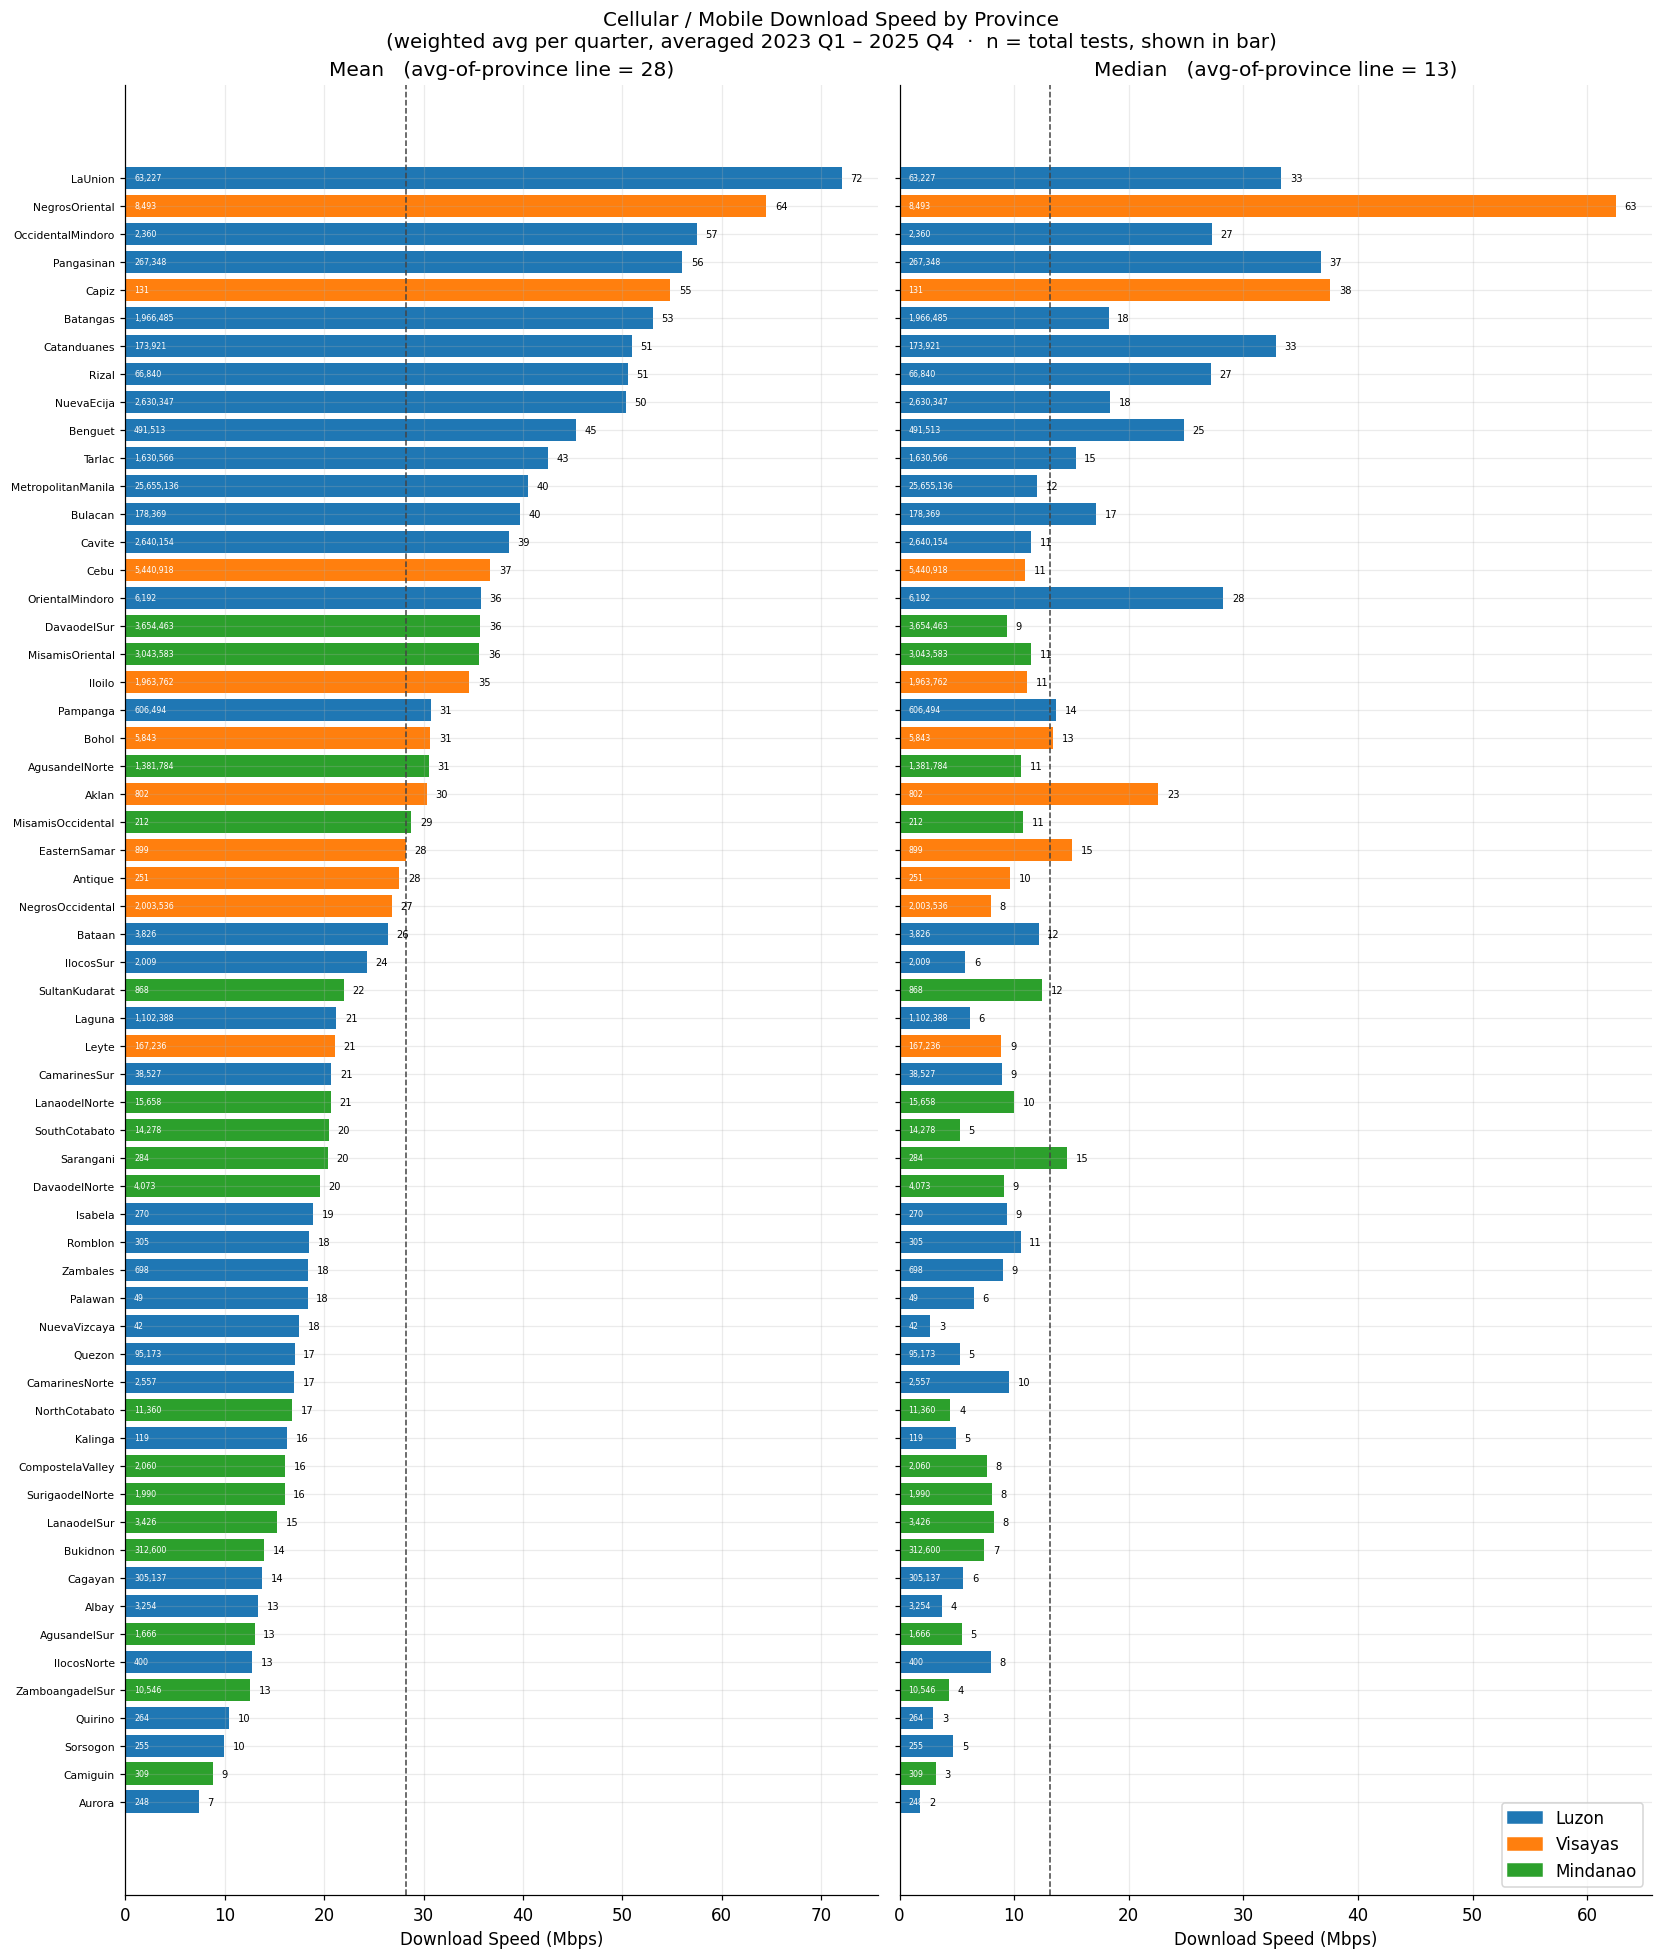

In [10]:
mobile_by_province = province_speed_figure(MOBILE, 'Cellular / Mobile')

# Part 5 · Heatmap พื้นที่ × เวลา (region × quarter)

รวมมิติพื้นที่ (region) กับเวลา (ไตรมาส) ไว้ในภาพเดียว — แต่ละช่อง = ความเร็ว download ของ region นั้นในไตรมาสนั้น สี YlOrRd (เข้ม = เร็ว) เรียง region ตามความเร็วรวม (เร็วสุดอยู่บน)

- อ่าน **แนวนอน** = region หนึ่งพัฒนาตามเวลายังไง (ซ้าย→ขวา เข้มขึ้น = เร็วขึ้น)
- อ่าน **แนวตั้ง** = ไตรมาสหนึ่ง region ไหนเร็ว/ช้า (บน→ล่าง = เหนือ→ใต้ ตาม digital divide)
- ทำทั้ง **mean** และ **median** × **broadband** และ **cellular** = 4 heatmap · ช่องเทา = ไม่มีข้อมูล · สเกลสี cap ที่ p97 กัน outlier · ใช้ `reg_map` จาก Geographic mapping cell

### Mean — Fixed broadband

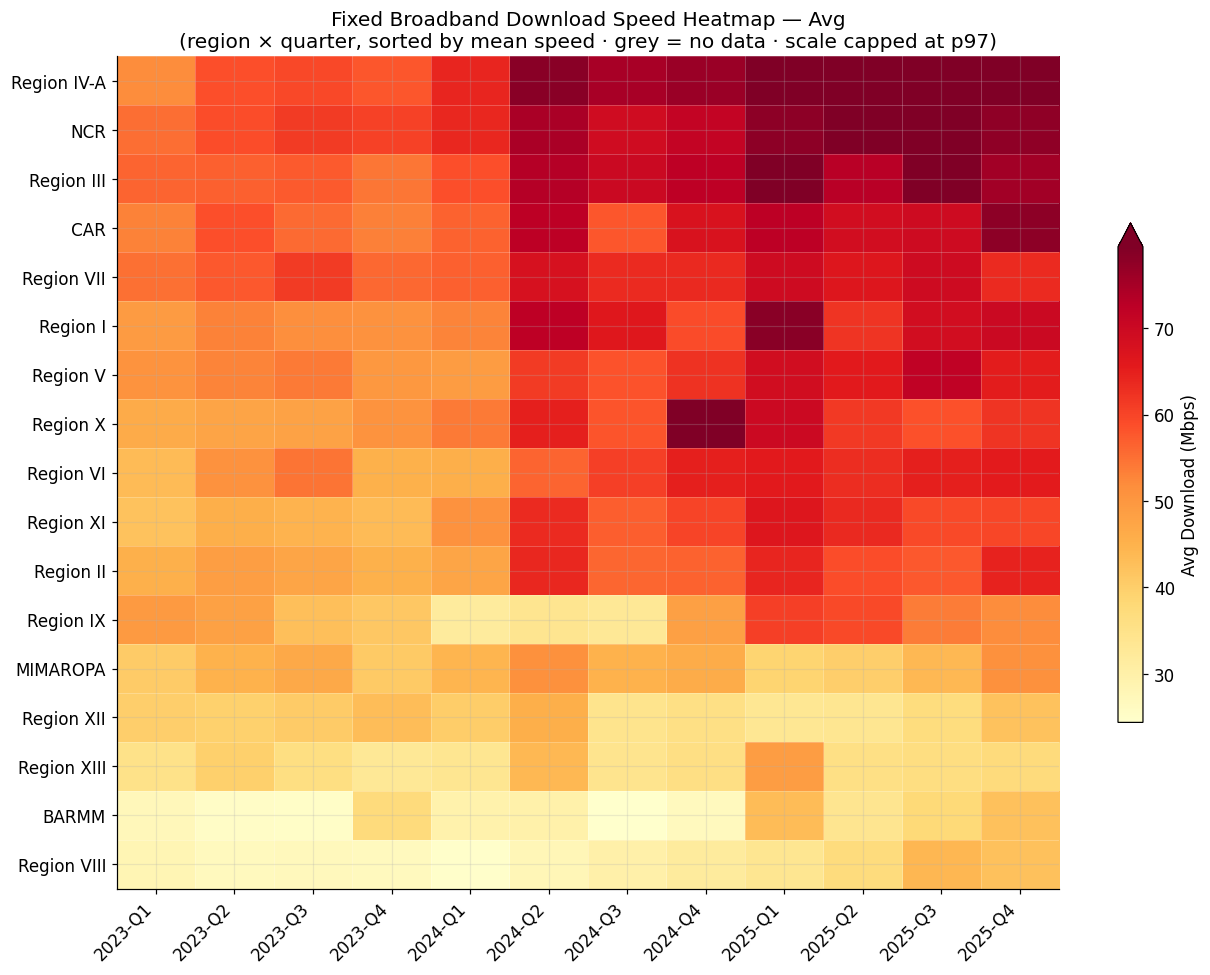

In [11]:
import matplotlib

def speed_heatmap(net_pred, label, stat='mean'):
    """Region × quarter heatmap of download speed (YlOrRd). `stat` = 'mean' or 'median'.
    Rows sorted by overall value (fastest at top). Missing region×quarter cells are shown in
    grey; the colour scale is capped at the 97th percentile so a few small-sample outlier
    quarters don't wash out the rest. Uses reg_map from the Geographic mapping cell."""
    agg_fn = 'AVG' if stat == 'mean' else 'MEDIAN'
    metric = 'Avg' if stat == 'mean' else 'Median'
    hm = q(f"""
        SELECT m.region,
               t.year || '-Q' || CAST(CEIL(t.month/3.0) AS INT) AS yq,
               {agg_fn}(t.mean_throughput_mbps) AS val
        FROM t JOIN reg_map m ON t.province = m.province
        WHERE {net_pred} AND {DL}
        GROUP BY 1, 2
    """)
    piv = hm.pivot(index='region', columns='yq', values='val')
    piv = piv[sorted(piv.columns)]                                      # quarters left->right
    piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]  # fastest region on top

    cmap = matplotlib.colormaps['YlOrRd'].copy()
    cmap.set_bad('#dddddd')                                             # grey = no data
    vmax = np.nanpercentile(piv.values, 97)                             # tame small-sample spikes

    fig, ax = plt.subplots(figsize=(12, 9))
    im = ax.imshow(np.ma.masked_invalid(piv.values), aspect='auto', cmap=cmap, vmax=vmax)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    # thin white gridlines to separate cells
    ax.set_xticks(np.arange(-.5, len(piv.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(piv.index), 1), minor=True)
    ax.grid(which='minor', color='white', lw=0.6)
    ax.tick_params(which='minor', length=0)
    cb = fig.colorbar(im, ax=ax, shrink=0.6, extend='max')
    cb.set_label(f'{metric} Download (Mbps)')
    ax.set_title(f'{label} Download Speed Heatmap — {metric}\n'
                 f'(region × quarter, sorted by {stat} speed · grey = no data · scale capped at p97)')
    plt.tight_layout()
    plt.show()
    return piv

heatmap_fixed_mean = speed_heatmap(FIXED, 'Fixed Broadband', stat='mean')

### Mean — Cellular / Mobile

เหมือนด้านบน แต่เปลี่ยนเป็น mobile — สเกลสี (colorbar) ปรับอัตโนมัติตามค่าของ mobile ที่ต่ำกว่า จึงเทียบสีข้าม heatmap ตรง ๆ ไม่ได้ ให้ดู colorbar ประกอบ

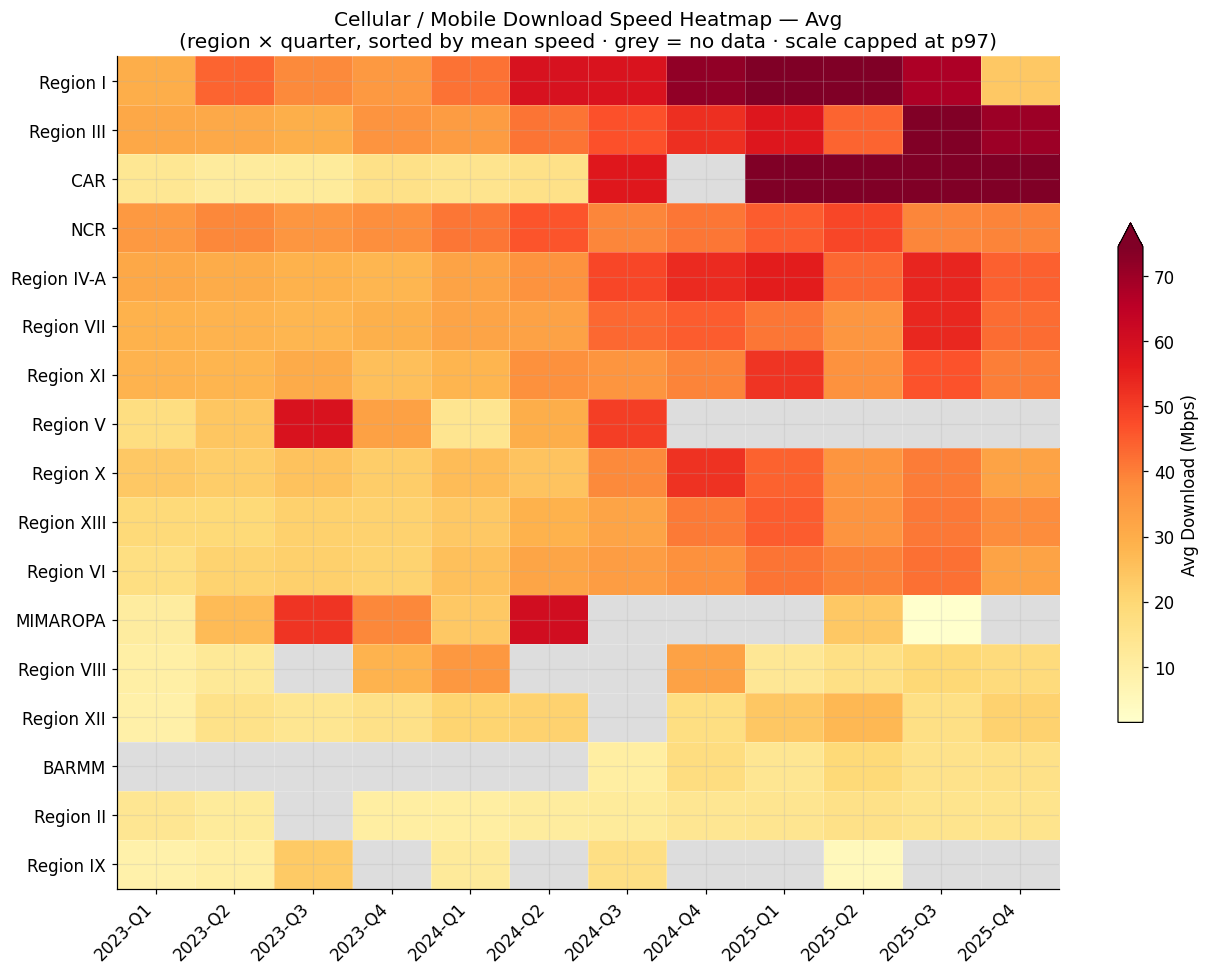

In [12]:
heatmap_mobile_mean = speed_heatmap(MOBILE, 'Cellular / Mobile', stat='mean')

### Median — Fixed broadband

เวอร์ชัน **median** (`stat='median'`) — ค่ากลางของ "ผู้ใช้ทั่วไป" ไม่โดน connection เร็วสุดๆ ลากขึ้นเหมือน mean จึงสะท้อนประสบการณ์จริงของคนส่วนใหญ่ในแต่ละ region×ไตรมาสได้ดีกว่า

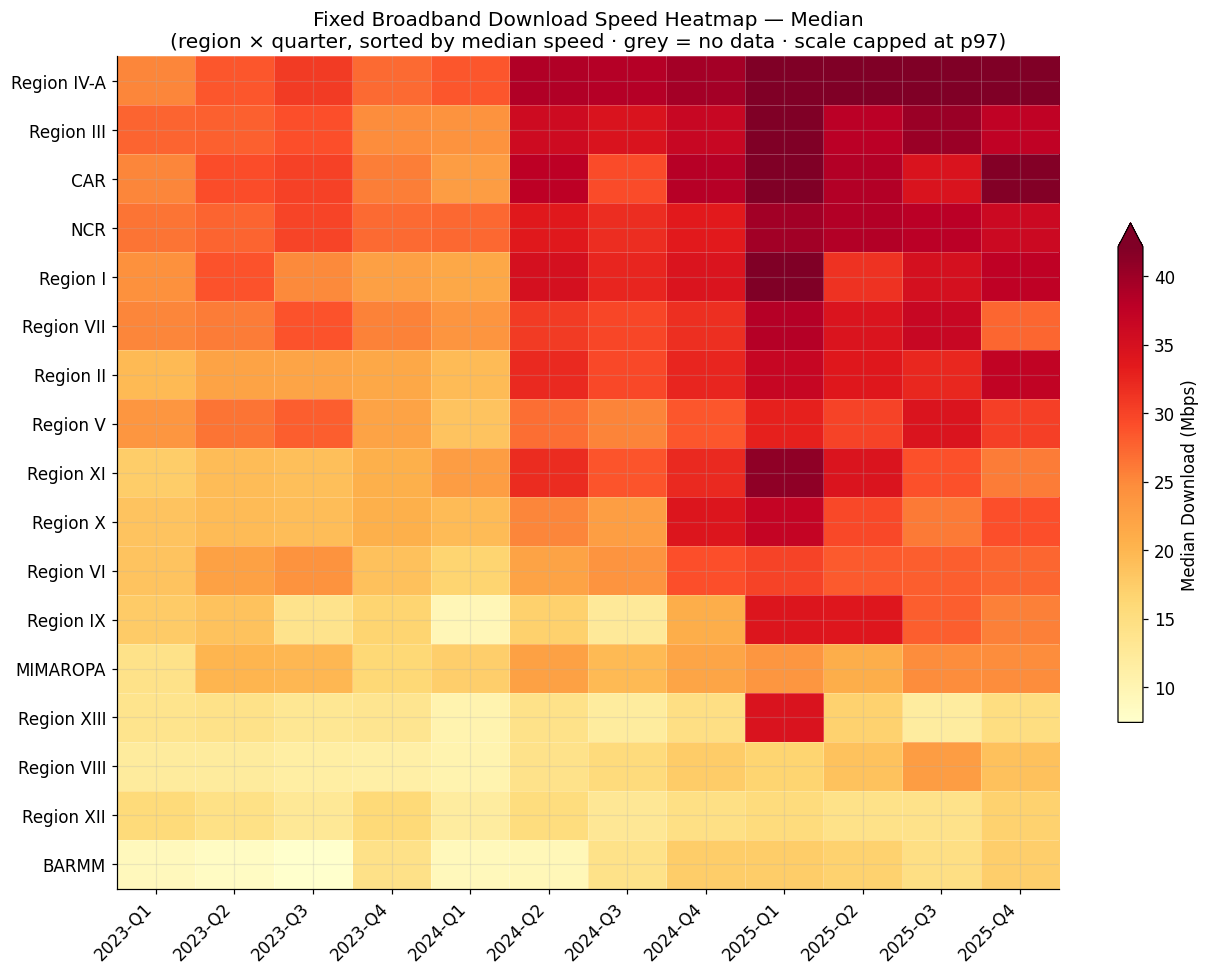

In [13]:
heatmap_fixed_median = speed_heatmap(FIXED, 'Fixed Broadband', stat='median')

### Median — Cellular / Mobile

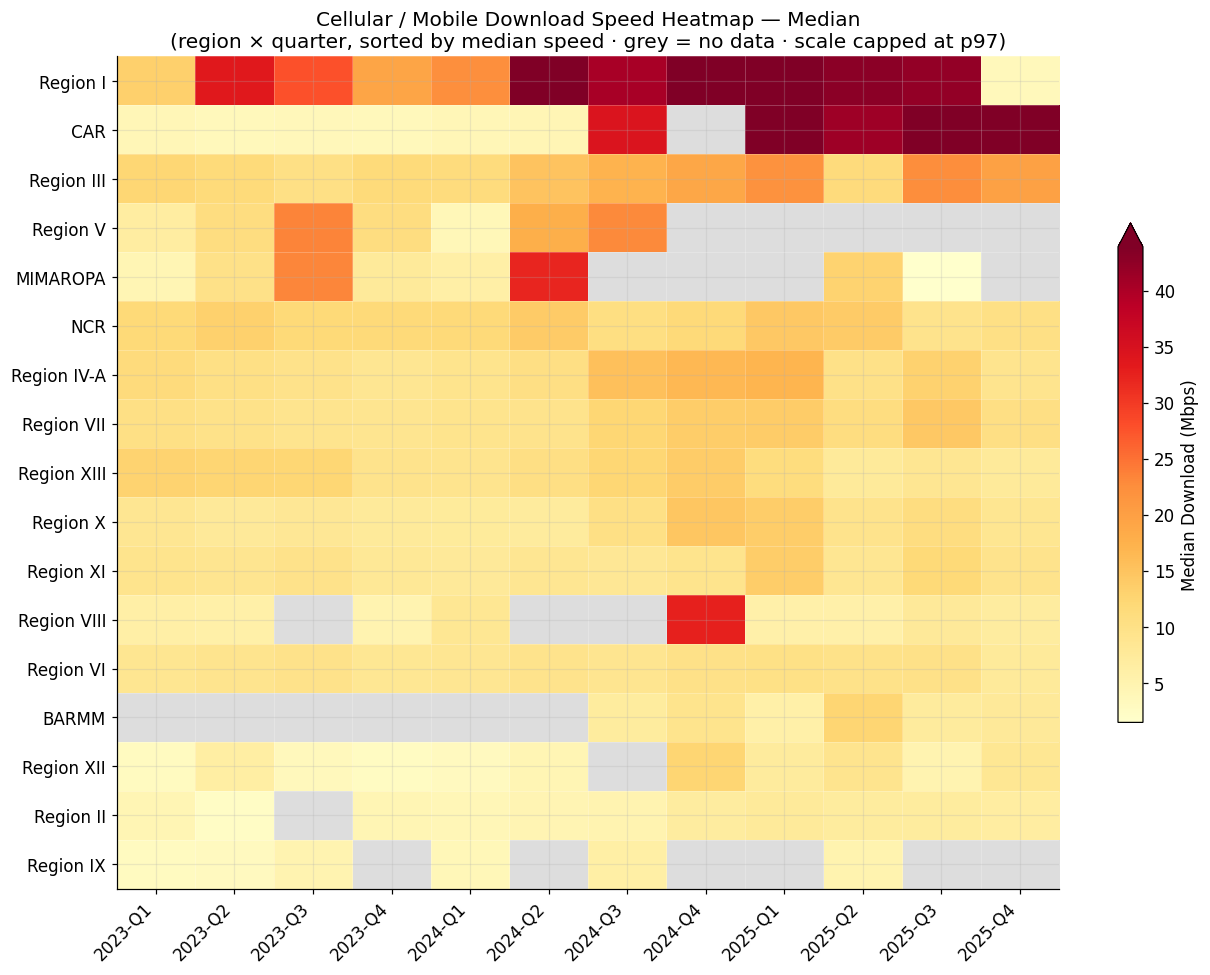

In [14]:
heatmap_mobile_median = speed_heatmap(MOBILE, 'Cellular / Mobile', stat='median')

# Part 6 · การเติบโตตามเวลา รายภูมิภาค (17 regions, 2023 Q1 → 2025 Q4)

มิติเวลาของ digital divide: fixed broadband ของแต่ละ **region** (17 หน่วย — ไม่ใช่ island) **โตขึ้นกี่ %** จากไตรมาสแรก (2023 Q1) ถึงไตรมาสสุดท้าย (2025 Q4)

- growth% = (ค่า 2025 Q4 − ค่า 2023 Q1) / ค่า 2023 Q1 × 100 · คำนวณระดับ region (base ปี 2023 Q1 ทุก region มี n > 10,000 จึงเชื่อถือได้ — ระดับจังหวัดจะ noise เกินไป)
- ทำทั้ง **median growth** (panel ซ้าย) และ **mean growth** (panel ขวา) — แต่ละ panel เรียง ranking ของตัวเอง **สีของแท่งระบายตาม island ที่ region นั้นสังกัด** (แค่สี ไม่ใช่หน่วยที่แสดงบนแกน) · เส้นประแดง = ค่าเฉลี่ย growth ของทุก region

> **ข้อควรระวัง:** median กับ mean growth ให้ผลต่างกันมากในบาง region (เช่น Cagayan Valley, Zamboanga) — median สะท้อน "ผู้ใช้ทั่วไป" ส่วน mean ไวต่อ connection เร็ว ๆ ที่เพิ่มเข้ามา ควรดูคู่กัน

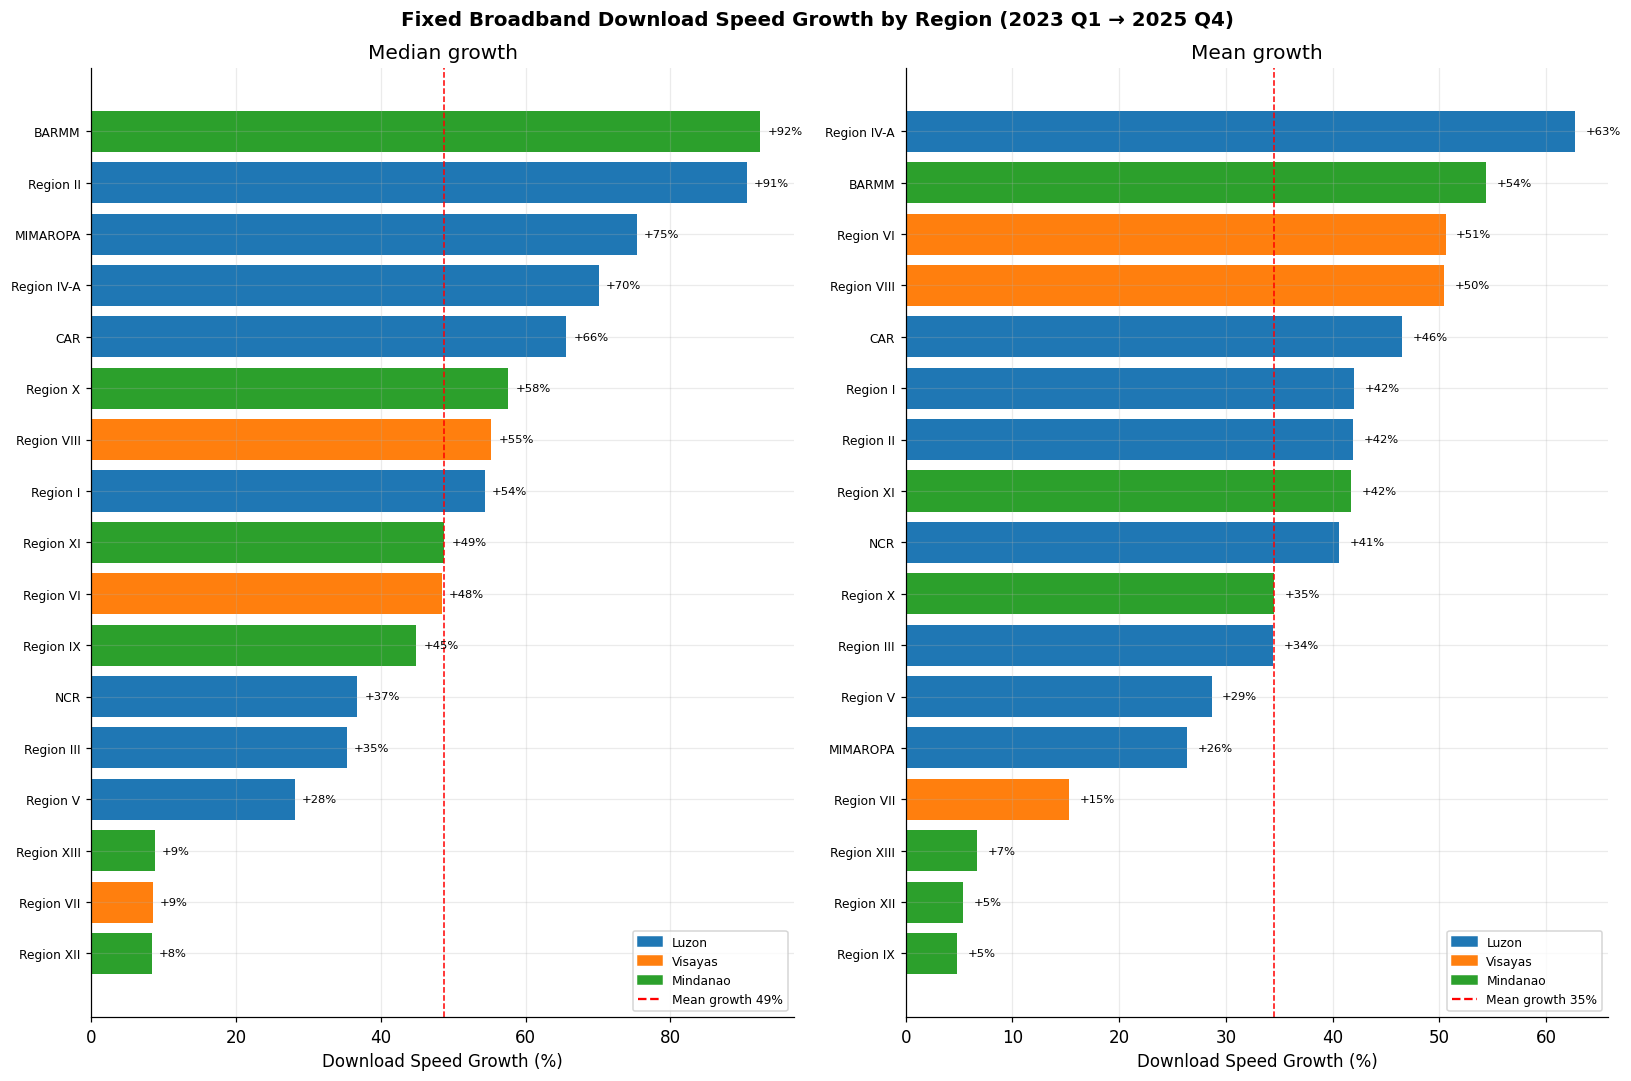

,region,island,med_base,med_end,median_growth,mean_growth
13,BARMM,Mindanao,9.0,17.3,92.4,54.4
5,Region II,Luzon,19.5,37.2,90.6,41.9
12,MIMAROPA,Luzon,14.1,24.8,75.3,26.3
14,Region IV-A,Luzon,25.3,43.1,70.1,62.7
6,CAR,Luzon,25.2,41.8,65.6,46.5
7,Region X,Mindanao,18.4,29.0,57.6,34.5
1,Region VIII,Visayas,12.1,18.8,55.3,50.4
2,Region I,Luzon,24.3,37.5,54.4,42.0
16,Region XI,Mindanao,17.4,25.9,48.7,41.7
11,Region VI,Visayas,18.5,27.4,48.4,50.6


In [15]:
growth = q("""
    SELECT m.region, m.island,
           MEDIAN(CASE WHEN year=2023 AND month IN (1,2,3)    THEN mean_throughput_mbps END) AS med_base,
           MEDIAN(CASE WHEN year=2025 AND month IN (10,11,12) THEN mean_throughput_mbps END) AS med_end,
           AVG(CASE    WHEN year=2023 AND month IN (1,2,3)    THEN mean_throughput_mbps END) AS mean_base,
           AVG(CASE    WHEN year=2025 AND month IN (10,11,12) THEN mean_throughput_mbps END) AS mean_end,
           SUM(CASE WHEN year=2023 AND month IN (1,2,3) THEN 1 ELSE 0 END) AS n_base
    FROM t JOIN reg_map m ON t.province = m.province
    WHERE network_type='broadband' AND type='download'
    GROUP BY 1, 2
""")
growth['median_growth'] = 100 * (growth['med_end']  - growth['med_base'])  / growth['med_base']
growth['mean_growth']   = 100 * (growth['mean_end'] - growth['mean_base']) / growth['mean_base']
assert (growth['n_base'] > 5000).all(), 'some region has a thin 2023 Q1 base — growth would be noisy'

from matplotlib.lines import Line2D
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 10))
for ax, col, ttl in [(a1, 'median_growth', 'Median growth'), (a2, 'mean_growth', 'Mean growth')]:
    d = growth.sort_values(col).reset_index(drop=True)   # smallest at bottom, largest at top
    y = np.arange(len(d))
    ax.barh(y, d[col], color=[ISLAND_COLORS[i] for i in d['island']])
    for yi, v in zip(y, d[col]):
        ax.text(v + (1 if v >= 0 else -1), yi, f'{v:+.0f}%',
                va='center', ha='left' if v >= 0 else 'right', fontsize=7.5)
    mg = d[col].mean()
    ml = ax.axvline(mg, ls='--', color='red', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(d['region'], fontsize=8)
    ax.set_title(ttl)
    ax.set_xlabel('Download Speed Growth (%)')
    handles = [Patch(color=c, label=l) for l, c in ISLAND_COLORS.items()] + \
              [Line2D([0], [0], color='red', ls='--', label=f'Mean growth {mg:.0f}%')]
    ax.legend(handles=handles, loc='lower right', fontsize=8)

fig.suptitle('Fixed Broadband Download Speed Growth by Region (2023 Q1 → 2025 Q4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

growth[['region', 'island', 'med_base', 'med_end', 'median_growth', 'mean_growth']].round(1) \
      .sort_values('median_growth', ascending=False)

# Part 7 · เน็ตใน 1 วัน (diurnal pattern) — network congestion

อินเทอร์เน็ต PH เปลี่ยนไปยังไงตลอด 24 ชั่วโมง — เส้น median download ของ fixed vs mobile ตาม **ชั่วโมงเวลาท้องถิ่น PH (UTC+8)** พร้อมแท่งเทา = จำนวน test ต่อชั่วโมง (บอกว่าคนใช้เน็ตหนักช่วงไหน)

- **สำคัญเรื่อง timezone:** คอลัมน์ `hour` ดิบเป็น **UTC** (จาก M-Lab) จึงแปลงเป็นเวลา PH ด้วย `(hour + 8) % 24` — ยืนยันถูกต้องเพราะ test-volume พีคที่ ~20:00 น. (สองทุ่ม) ตรงกับพฤติกรรมใช้เน็ตช่วงเย็นจริง
- แถบแดง = ช่วง peak-usage (19:00–23:00) · ยิ่งคนออนไลน์เยอะ ความเร็วยิ่งตก = network congestion แบบตำรา

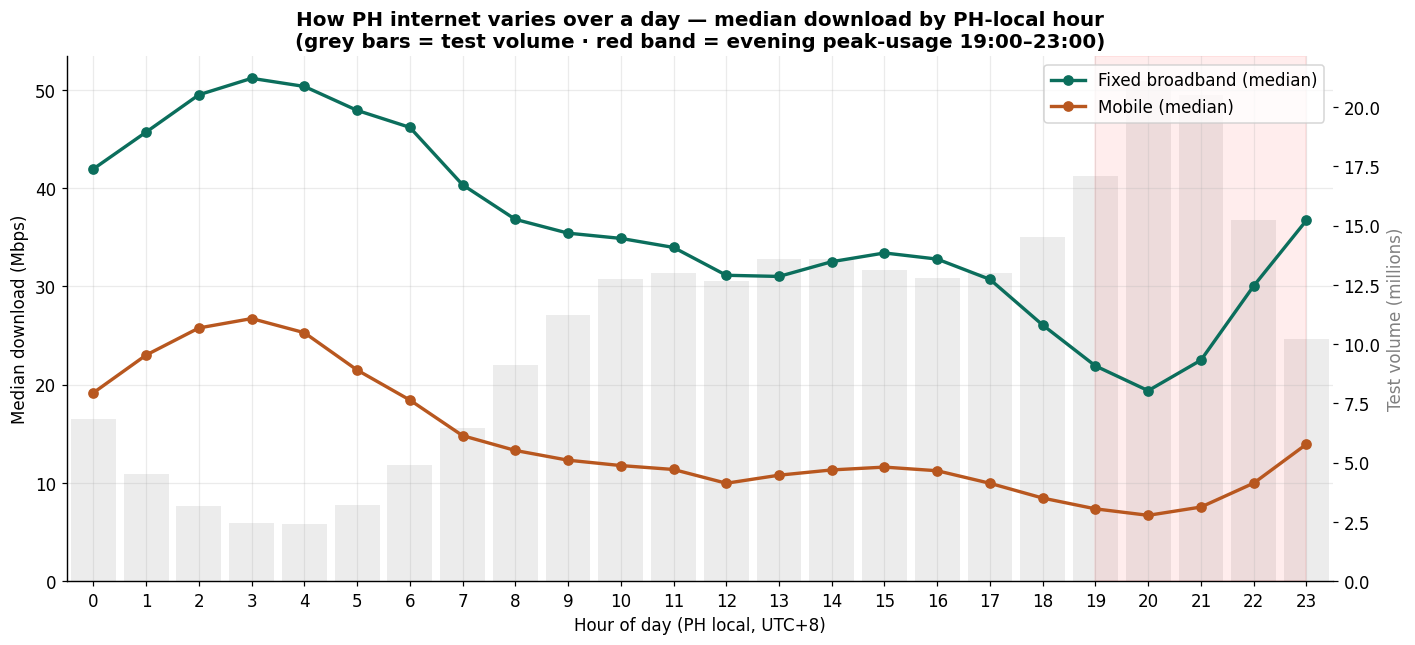

Fixed  median — best hour 03:00 = 51.2 Mbps  |  worst hour 20:00 = 19.4 Mbps  (62% slower at peak)


In [16]:
# `hour` is derived from test_time (UTC). PH local time = (hour + 8) % 24
daily = q("""
    SELECT (hour + 8) % 24 AS ph_hour,
           COUNT(*)                                                               AS tests,
           MEDIAN(CASE WHEN network_type='broadband' AND type='download' THEN mean_throughput_mbps END) AS fixed_med,
           MEDIAN(CASE WHEN network_type='cellular'  AND type='download' THEN mean_throughput_mbps END) AS mobile_med
    FROM t
    WHERE network_type IN ('broadband', 'cellular')
    GROUP BY 1 ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(13, 6))

# test-volume bars on a secondary axis (context: when are people online)
ax2 = ax.twinx()
ax2.bar(daily['ph_hour'], daily['tests'] / 1e6, width=0.85, alpha=0.15, color='grey', zorder=1)
ax2.set_ylabel('Test volume (millions)', color='grey')
ax2.grid(False)

# peak-usage window highlight
ax.axvspan(19, 23, alpha=0.07, color='red', zorder=0)

# median download lines
ax.plot(daily['ph_hour'], daily['fixed_med'],  'o-', color=C_FIXED,  lw=2.2, label='Fixed broadband (median)', zorder=3)
ax.plot(daily['ph_hour'], daily['mobile_med'], 'o-', color=C_MOBILE, lw=2.2, label='Mobile (median)',          zorder=3)
ax.set_xlabel('Hour of day (PH local, UTC+8)')
ax.set_ylabel('Median download (Mbps)')
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, None)
ax.legend(loc='upper right')
ax.set_zorder(ax2.get_zorder() + 1)   # lines above bars
ax.patch.set_visible(False)
ax.set_title('How PH internet varies over a day — median download by PH-local hour\n'
             '(grey bars = test volume · red band = evening peak-usage 19:00–23:00)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# quick numbers: best vs worst hour
best = daily.loc[daily['fixed_med'].idxmax()]
worst = daily.loc[daily['fixed_med'].idxmin()]
print(f"Fixed  median — best hour {int(best.ph_hour):02d}:00 = {best.fixed_med:.1f} Mbps"
      f"  |  worst hour {int(worst.ph_hour):02d}:00 = {worst.fixed_med:.1f} Mbps"
      f"  ({100*(best.fixed_med-worst.fixed_med)/best.fixed_med:.0f}% slower at peak)")

# Part 8 · ISP — ใครครองตลาด ใครเร็ว

วิเคราะห์รายผู้ให้บริการ (`isp`) — story หลักคือ **"เจ้าใหญ่สุด ≠ เร็วสุด"**

> **หมายเหตุ:** บางแบรนด์ปรากฏหลายชื่อในข้อมูล (เช่น `Converge ICT Solutions Inc.` กับ `Converge ICT`, และ Globe แยก `Globe Telecom Inc.`/`Globe Telecoms` ตาม ASN) — ใช้ `isp` ดิบตามที่ M-Lab ให้มา ไม่ได้ merge เพราะบางคู่เป็นคนละ ASN จริง

### 1. ISP รายใหญ่สุด — top 10 ตามจำนวน test (fixed | mobile)

จุดตั้งต้นของ Part 8: ใครมีปริมาณการใช้งานมากที่สุดในแต่ละตลาด แยก fixed broadband กับ mobile คนละ panel
เพราะเป็นคนละตลาดกัน (ISP เจ้าหนึ่งอาจใหญ่ในฝั่งเดียว)

- **แท่ง = จำนวน test** (1 test = 1 ทิศทาง download หรือ upload แยกแถวกัน) · **% = ส่วนแบ่งของ test ทั้งหมดในตลาดนั้น**
- **unique client IP อยู่ในตารางที่ print ใต้กราฟ** (ใส่ในแท่งไม่ได้ ISP เล็ก ๆ แท่งสั้นเกินจนตัวเลขล้นหาย)
  พร้อมคอลัมน์ **tests/IP** = จำนวน test เฉลี่ยต่อ 1 IP



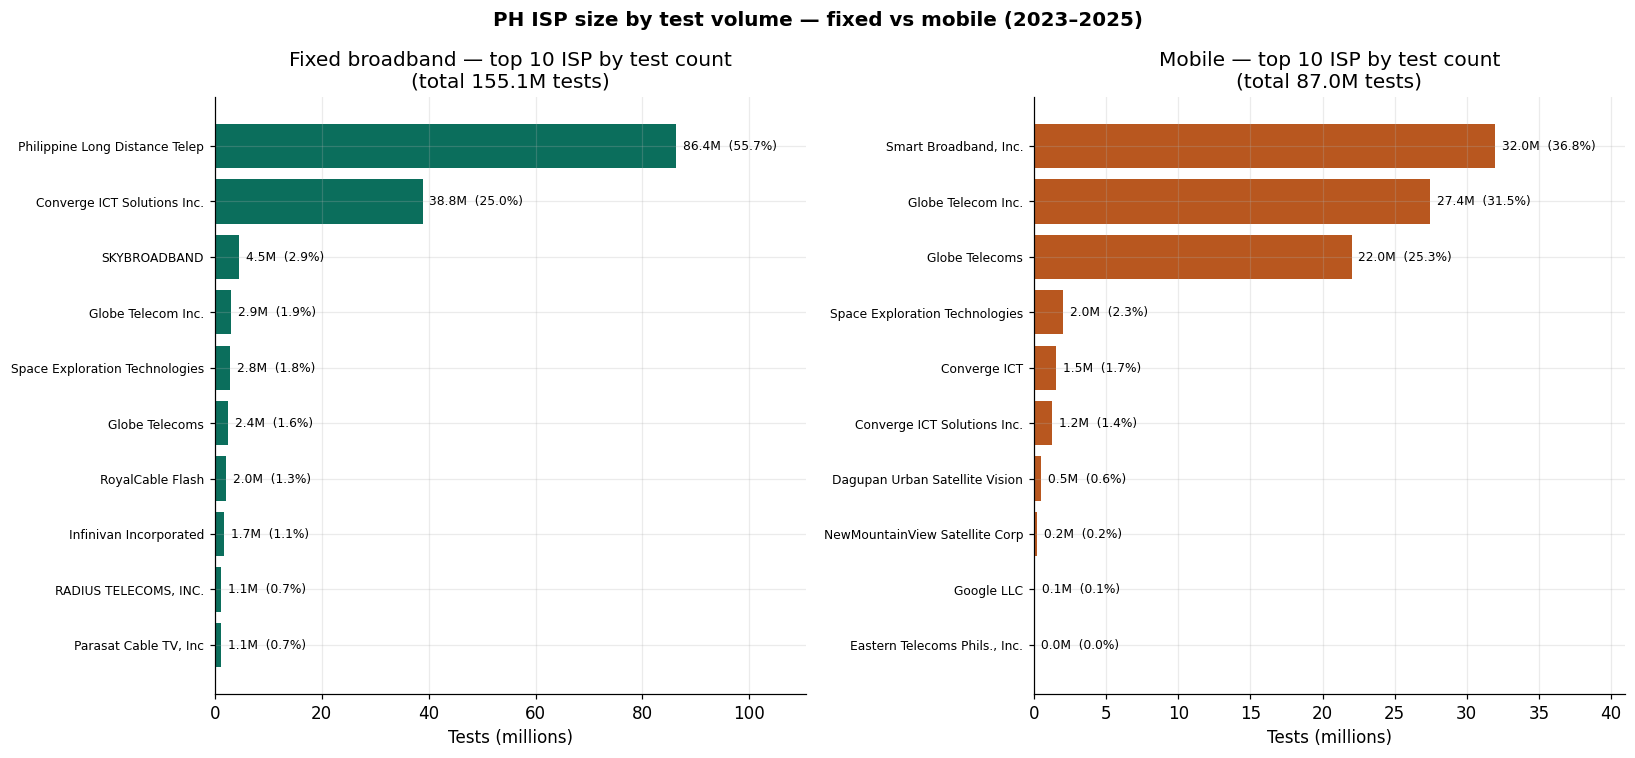


Fixed broadband — top 10 ISP
 #  ISP                                                 tests   share   unique IPs  tests/IP
--------------------------------------------------------------------------------------------
 1  Philippine Long Distance Telephone Company     86,355,876   55.7%    9,798,750       8.8
 2  Converge ICT Solutions Inc.                    38,841,251   25.0%       50,601     767.6
 3  SKYBROADBAND                                    4,474,940    2.9%      386,230      11.6
 4  Globe Telecom Inc.                              2,930,725    1.9%       41,603      70.4
 5  Space Exploration Technologies Corporation      2,824,202    1.8%        5,579     506.2
 6  Globe Telecoms                                  2,409,431    1.6%       28,567      84.3
 7  RoyalCable Flash                                2,046,681    1.3%        3,355     610.0
 8  Infinivan Incorporated                          1,662,454    1.1%        5,988     277.6
 9  RADIUS TELECOMS, INC.               

In [17]:
def isp_count_top(net_pred, topn=10):
    """Top-N ISPs by raw test volume for one network type, with unique client IPs
    alongside (tests != users: a few heavy retesters can inflate the test count)."""
    return q(f"""
        SELECT isp,
               COUNT(*)                  AS tests,
               COUNT(DISTINCT client_ip) AS uniq_ips
        FROM t
        WHERE {net_pred} AND isp IS NOT NULL
        GROUP BY 1
        ORDER BY tests DESC
        LIMIT {topn}
    """)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
isp_counts = {}
for ax, net_pred, c, ttl in [(axes[0], FIXED,  C_FIXED,  'Fixed broadband'),
                             (axes[1], MOBILE, C_MOBILE, 'Mobile')]:
    top = isp_count_top(net_pred)
    # share is measured against the WHOLE segment, not just the top 10
    seg_total = q(f"SELECT COUNT(*) n FROM t WHERE {net_pred} AND isp IS NOT NULL")['n'][0]
    isp_counts[ttl] = top.assign(pct=100 * top['tests'] / seg_total,
                                 tests_per_ip=top['tests'] / top['uniq_ips'])

    d = top.iloc[::-1].reset_index(drop=True)          # biggest at the top of the bar chart
    y = np.arange(len(d))
    ax.barh(y, d['tests'] / 1e6, color=c)
    mx = (d['tests'] / 1e6).max()
    # labels go OUTSIDE the bar: the small ISPs' bars are far too short to hold text
    for yi, r in zip(y, d.itertuples()):
        ax.text(r.tests / 1e6 + mx * 0.015, yi,
                f'{r.tests/1e6:.1f}M  ({100*r.tests/seg_total:.1f}%)', va='center', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels([s[:30] for s in d['isp']], fontsize=8)
    ax.set_xlabel('Tests (millions)')
    ax.set_xlim(0, mx * 1.28)                          # room for the labels
    ax.set_title(f'{ttl} — top 10 ISP by test count\n(total {seg_total/1e6:.1f}M tests)')

fig.suptitle('PH ISP size by test volume — fixed vs mobile (2023–2025)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# unique-IP counts are printed as their own table: they do not fit legibly inside the bars,
# and tests/IP is the number that actually matters (see the CGNAT note below).
for seg, d in isp_counts.items():
    print(f'\n{seg} — top 10 ISP')
    print(f'{"#":>2}  {"ISP":<44}{"tests":>13}{"share":>8}{"unique IPs":>13}{"tests/IP":>10}')
    print('-' * 92)
    for rank, r in enumerate(d.itertuples(), 1):
        print(f'{rank:>2}  {r.isp[:43]:<44}{r.tests:>13,}{r.pct:>7.1f}%'
              f'{r.uniq_ips:>13,}{r.tests_per_ip:>10.1f}')


### 2. Market reach vs speed — biggest ≠ fastest
แต่ละจุด = 1 ISP · แกน x = จำนวน unique client IP (log scale = ขนาดฐานลูกค้า) · แกน y = median download · สีตาม fixed/mobile

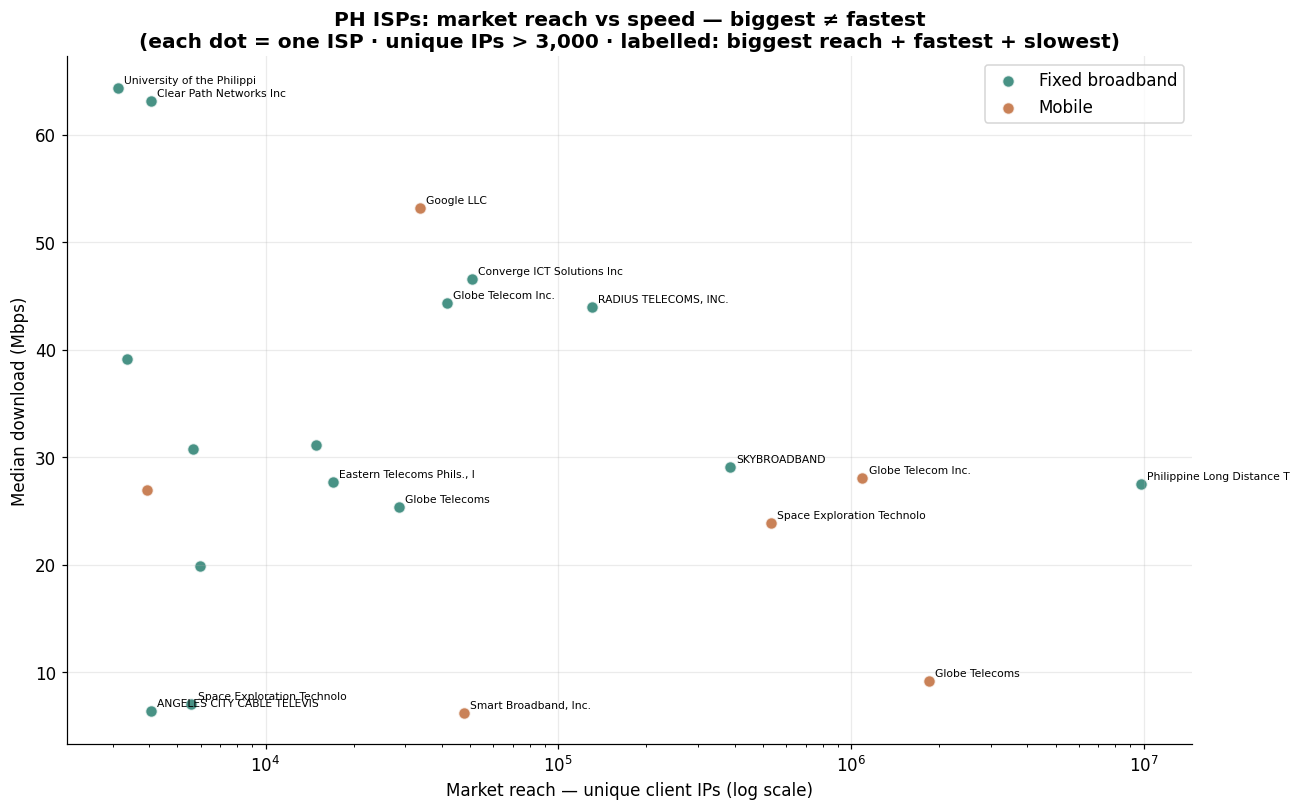

In [18]:
isp_scatter = q("""
    SELECT isp, network_type,
           COUNT(DISTINCT client_ip) AS uniq_ips,
           MEDIAN(CASE WHEN type='download' THEN mean_throughput_mbps END) AS dl_median
    FROM t
    WHERE network_type IN ('broadband', 'cellular') AND isp IS NOT NULL
    GROUP BY 1, 2
    HAVING COUNT(DISTINCT client_ip) > 3000
""")

fig, ax = plt.subplots(figsize=(12, 7.5))
for nt, c, lab in [('broadband', C_FIXED, 'Fixed broadband'), ('cellular', C_MOBILE, 'Mobile')]:
    s = isp_scatter[isp_scatter.network_type == nt]
    ax.scatter(s.uniq_ips, s.dl_median, s=60, color=c, alpha=0.75, edgecolor='white', label=lab)

# label three groups: biggest reach + fastest + slowest (so the extreme dots aren't anonymous)
to_label  = set(isp_scatter.sort_values('uniq_ips',  ascending=False).head(12).index)   # biggest reach
to_label |= set(isp_scatter.sort_values('dl_median', ascending=False).head(3).index)    # fastest
to_label |= set(isp_scatter.sort_values('dl_median').head(3).index)                      # slowest
for i in to_label:
    r = isp_scatter.loc[i]
    ax.annotate(r.isp[:26], (r.uniq_ips, r.dl_median), fontsize=7, xytext=(4, 3), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Market reach — unique client IPs (log scale)')
ax.set_ylabel('Median download (Mbps)')
ax.set_title('PH ISPs: market reach vs speed — biggest ≠ fastest\n'
             '(each dot = one ISP · unique IPs > 3,000 · labelled: biggest reach + fastest + slowest)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3. ISP speed ranking (fixed | mobile)

Top ISP เรียงตาม median download แยก fixed/mobile · กรอง ISP ที่มี test > 200,000 (กัน ISP จิ๋วที่ค่าผันผวน) · ตัวเลขในแท่ง = จำนวน test

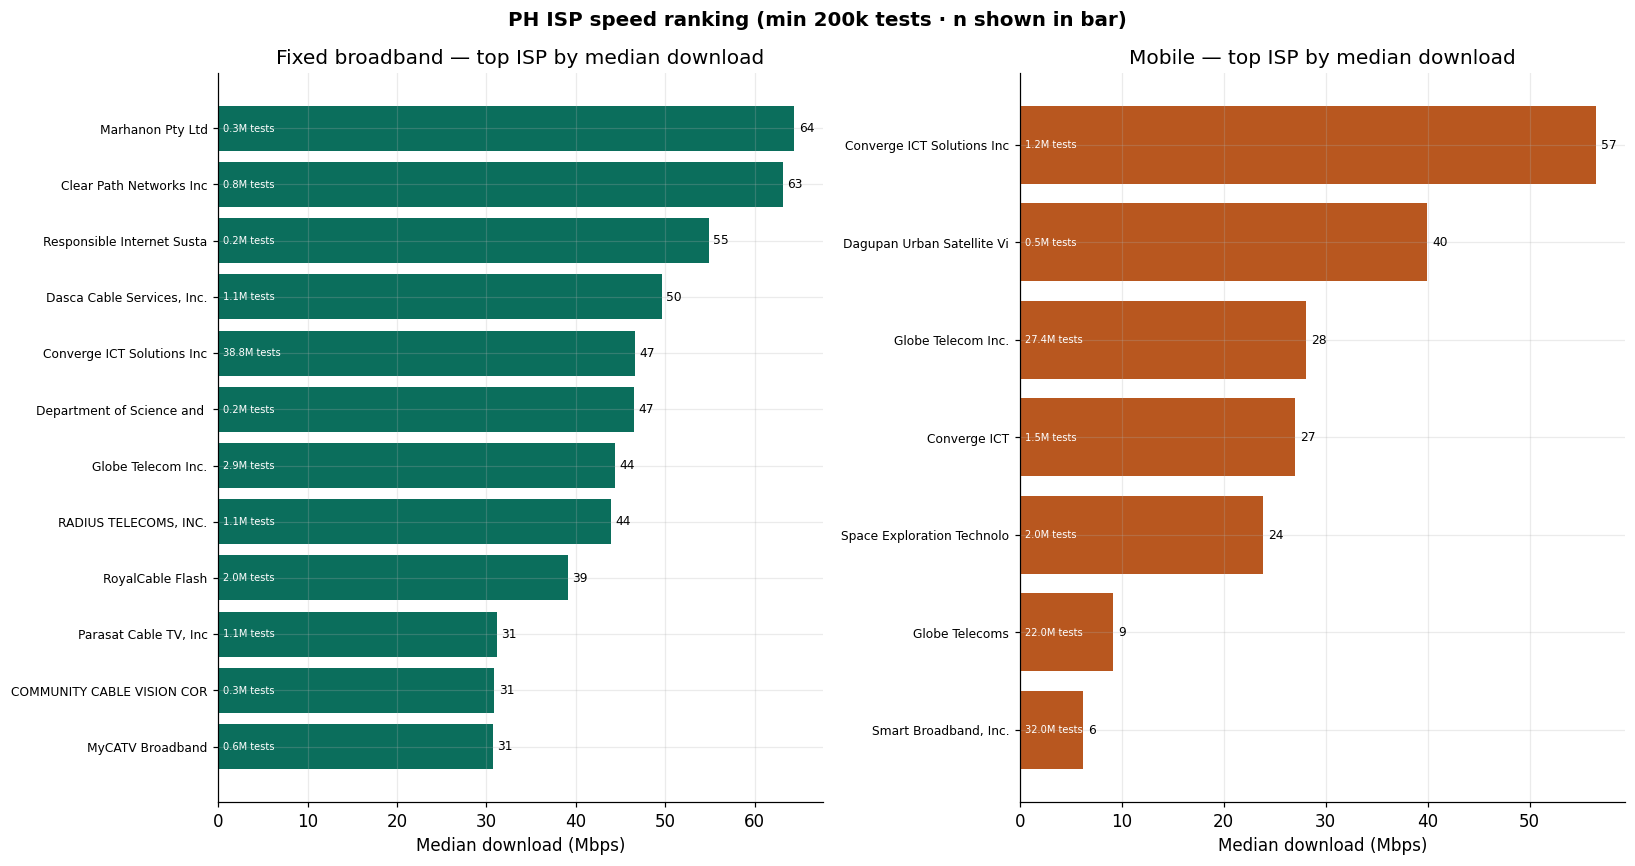

In [19]:
def isp_rank(net, topn=12, min_tests=200000):
    return q(f"""
        SELECT isp, COUNT(*) AS tests,
               MEDIAN(CASE WHEN type='download' THEN mean_throughput_mbps END) AS med
        FROM t WHERE {net} AND isp IS NOT NULL
        GROUP BY 1 HAVING COUNT(*) > {min_tests}
        ORDER BY med DESC LIMIT {topn}
    """).sort_values('med').reset_index(drop=True)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 8))
for ax, net, c, ttl in [(a1, FIXED, C_FIXED, 'Fixed broadband'), (a2, MOBILE, C_MOBILE, 'Mobile')]:
    r = isp_rank(net)
    y = np.arange(len(r))
    ax.barh(y, r['med'], color=c)
    for yi, row in zip(y, r.itertuples()):
        ax.text(row.med + 0.5, yi, f'{row.med:.0f}', va='center', fontsize=8)
        ax.text(0.5, yi, f'{row.tests/1e6:.1f}M tests', va='center', fontsize=6.5, color='white')
    ax.set_yticks(y)
    ax.set_yticklabels([s[:26] for s in r['isp']], fontsize=8)
    ax.set_title(f'{ttl} — top ISP by median download')
    ax.set_xlabel('Median download (Mbps)')
fig.suptitle('PH ISP speed ranking (min 200k tests · n shown in bar)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 4. ISP market share by island (fixed broadband)

ส่วนแบ่งตลาด (% ของ test) ของ ISP รายใหญ่ในแต่ละเกาะ — ดูว่าตลาดผูกขาดหรือแข่งขัน ผูกกับ digital divide (ยิ่งผูกขาด ยิ่งช้า) ใช้ `reg_map` แปลง province → island

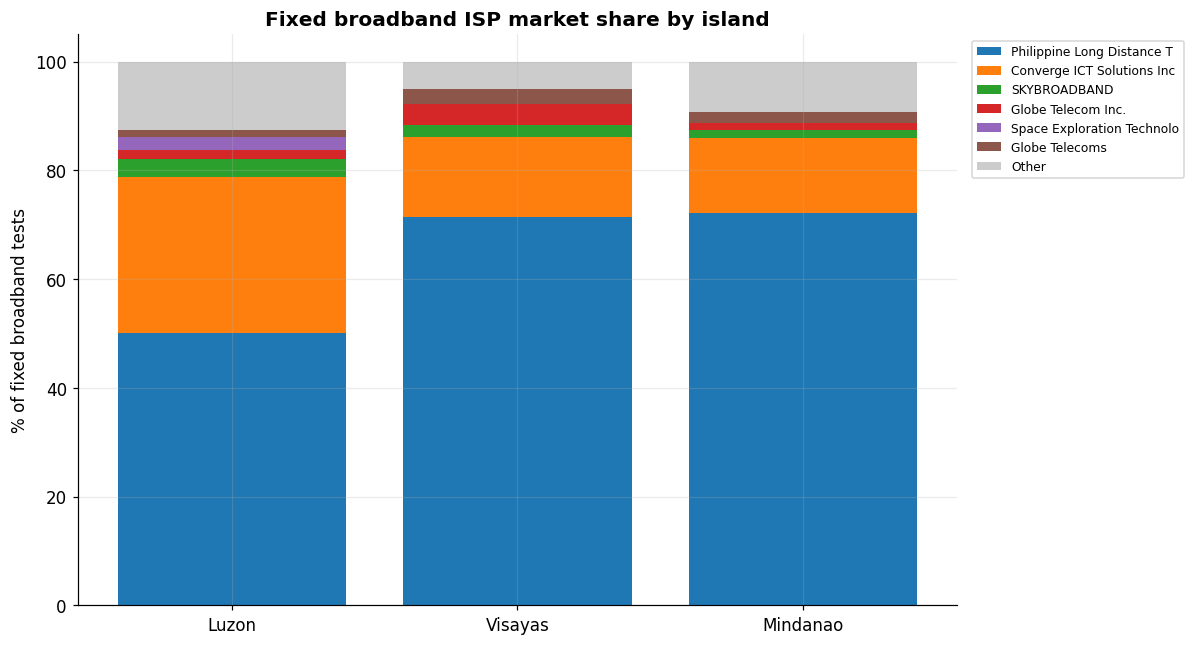

isp2,Philippine Long Distance Telephone Company,Converge ICT Solutions Inc.,SKYBROADBAND,Globe Telecom Inc.,Space Exploration Technologies Corporation,Globe Telecoms,Other
island,,,,,,,
Luzon,50.0,28.9,3.2,1.6,2.5,1.3,12.5
Visayas,71.5,14.6,2.3,3.8,0.0,2.7,5.1
Mindanao,72.1,13.9,1.4,1.3,0.0,2.0,9.3


In [20]:
sh = q("""
    SELECT m.island, t.isp, COUNT(*) AS tests
    FROM t JOIN reg_map m ON t.province = m.province
    WHERE network_type='broadband' AND isp IS NOT NULL
    GROUP BY 1, 2
""")
top_isps = sh.groupby('isp').tests.sum().sort_values(ascending=False).head(6).index.tolist()
sh['isp2'] = sh.isp.where(sh.isp.isin(top_isps), 'Other')
piv = sh.groupby(['island', 'isp2']).tests.sum().unstack(fill_value=0)
piv = piv.div(piv.sum(axis=1), axis=0) * 100
piv = piv.loc[['Luzon', 'Visayas', 'Mindanao']][ [c for c in top_isps if c in piv.columns] + ['Other'] ]

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(piv))
for i, c in enumerate(piv.columns):
    ax.bar(piv.index, piv[c], bottom=bottom,
           label=c[:26], color='#cccccc' if c == 'Other' else plt.cm.tab10(i))
    bottom += piv[c].values
ax.set_ylabel('% of fixed broadband tests')
ax.set_title('Fixed broadband ISP market share by island', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

piv.round(1)